# Temporal federation experiment explorer

This notebook compares every strategy registered in the experiment manifest across four independent rolling-origin challenges, three endpoints, and three deliberately separate evaluation scopes.

- **Primary view:** the immediately following temporal fold (`next_fold`).
- **Sensitivity views:** all remaining future data and the fixed final fold. These reuse compounds across origins and must not be read as independent challenges.
- **Uncertainty:** 95% intervals come from 1,000 full-size paired bootstrap draws over test rows and the crossed 5×5 seed design.
- **Testing:** the 25 full-test model fits are the repeated observations. Bootstrap draws are never counted as independent samples.
- **Scale:** pKi and LogD remain on their native logarithmic scales. Solubility is modelled and evaluated as `log10(1 + uM)`.


In [1]:
from pathlib import Path
from zipfile import ZipFile

_snapshot = Path("results_snapshot.zip")
_required = Path("temporal_experiment/analysis/full_metrics.csv")
if not _required.is_file():
    if not _snapshot.is_file():
        raise FileNotFoundError(
            "Neither the extracted analysis tables nor results_snapshot.zip is available"
        )
    with ZipFile(_snapshot) as _archive:
        _archive.extractall(Path("."))
    print("Expanded the compact analysis snapshot for this workbook.")

from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from IPython.display import display, Markdown

RESULTS_DIR = Path("temporal_experiment")
ANALYSIS_DIR = RESULTS_DIR / "analysis"
manifest = json.loads((RESULTS_DIR / "experiment_manifest.json").read_text())
analysis_manifest = json.loads((ANALYSIS_DIR / "analysis_manifest.json").read_text())

full_metrics = pd.read_csv(ANALYSIS_DIR / "full_metrics.csv")
bootstrap_summary = pd.read_csv(ANALYSIS_DIR / "bootstrap_summary.csv")
bootstrap_metrics = pd.read_csv(ANALYSIS_DIR / "bootstrap_metrics.csv.xz")
pairwise_bootstrap = pd.read_csv(ANALYSIS_DIR / "pairwise_bootstrap_summary.csv")
significance = pd.read_csv(ANALYSIS_DIR / "per_origin_significance.csv")
global_significance = pd.read_csv(ANALYSIS_DIR / "global_significance.csv")
omnibus = pd.read_csv(ANALYSIS_DIR / "omnibus_tests.csv")
pairwise_tests = pd.read_csv(ANALYSIS_DIR / "pairwise_tests.csv")
residuals = pd.read_csv(ANALYSIS_DIR / "anova_residuals.csv")
points = pd.read_csv(ANALYSIS_DIR / "prediction_points.csv.xz")
for family_frame in (significance, global_significance, omnibus, pairwise_tests, residuals):
    if "comparison_family" not in family_frame:
        family_frame["comparison_family"] = "prospective_multitask"
for baseline_frame in (pairwise_bootstrap, significance, global_significance):
    if "baseline_strategy" not in baseline_frame:
        baseline_frame["baseline_strategy"] = "scratch"
for mixed_origin_frame in (omnibus, pairwise_tests, residuals):
    mixed_origin_frame["origin_number"] = pd.to_numeric(mixed_origin_frame["origin"], errors="coerce")

STRATEGIES = manifest["strategies"]
TARGETS = manifest["model_targets"]
TARGET_LABEL = {item["model_column"]: item["display_name"] for item in manifest["target_transforms"]}
STRATEGY_LABEL = {
    "scratch": "Scratch",
    "scratch_single_task": "Scratch: single-task",
    "scratch_conservative_lr": "Scratch: conservative LR",
    "scratch_continual_cumulative": "Scratch continual: cumulative",
    "scratch_continual_replay": "Scratch continual: 20% replay",
    "scratch_continual_similarity_replay": "Scratch continual: similarity replay",
    "scratch_continual_similarity_matched_random": "Scratch continual: matched random",
    "scratch_continual_incremental": "Scratch continual: incremental",
    "foundation_finetune": "Foundation: fine-tune",
    "foundation_finetune_single_task": "Foundation: single-task",
    "chemeleon_finetune": "CheMeleon: fine-tune",
    "chemeleon_finetune_single_task": "CheMeleon: single-task",
    "chemeleon_conservative_lr": "CheMeleon: conservative LR",
    "chemeleon_frozen": "CheMeleon: frozen encoder",
    "chemeleon_staged_unfreeze": "CheMeleon: staged unfreeze",
    "chemeleon_continual_cumulative": "CheMeleon continual: cumulative",
    "chemeleon_continual_replay": "CheMeleon continual: 20% replay",
    "chemeleon_continual_similarity_replay": "CheMeleon continual: similarity replay",
    "chemeleon_continual_similarity_matched_random": "CheMeleon continual: matched random",
    "chemeleon_continual_incremental": "CheMeleon continual: incremental",
    "foundation_conservative_lr": "Foundation: conservative LR",
    "foundation_frozen": "Foundation: frozen encoder",
    "foundation_staged_unfreeze": "Foundation: staged unfreeze",
    "continual_cumulative": "Continual: cumulative",
    "continual_replay": "Continual: 20% replay",
    "continual_similarity_replay": "Continual: similarity replay",
    "continual_similarity_matched_random": "Continual: matched random",
    "continual_incremental": "Continual: incremental",
    "transductive_similarity_filtered": "Transductive: next-fold similarity",
}
if "historical_replay" in manifest:
    STRATEGY_LABEL["continual_replay"] = (
        f"Continual: {manifest['historical_replay']['fraction']:.0%} replay"
    )
palette_name = "colorblind" if len(STRATEGIES) <= 10 else "husl"
PALETTE = dict(zip(STRATEGIES, sns.color_palette(palette_name, len(STRATEGIES))))
STRATEGY_COMPARATOR = manifest.get(
    "strategy_comparators", {strategy: "scratch" for strategy in STRATEGIES if strategy != "scratch"}
)
TRANSDUCTIVE_STRATEGIES = {"transductive_similarity_filtered"}
LOWER_IS_BETTER = {"rmse", "mae", "mse", "median_absolute_error", "smape", "max_absolute_error"}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
display(pd.DataFrame(manifest["folds"]))


,temporal_fold,n_rows,n_dates,date_start,date_end
0,1,202,81,2001-07-31,2002-11-26
1,2,204,44,2002-11-27,2003-05-13
2,3,205,20,2003-05-15,2003-08-18
3,4,206,85,2003-08-22,2004-08-06
4,5,198,66,2004-08-10,2007-09-19


## 0. Result coverage audit

This table is a hard completeness check, not just a summary. The notebook stops here if any strategy registered in the experiment manifest is absent or lacks any rolling origin, crossed seed replicate, evaluation scope, endpoint, or metric row. Consequently, every downstream view is guaranteed to use the complete combined experiment rather than a partially finished run.


In [2]:
EXPECTED_ORIGINS = len(manifest["rolling_origins"])
EXPECTED_REPLICATES = len(manifest["data_seeds"]) * len(manifest["pytorch_seeds"])
EXPECTED_SCOPES = len(manifest["evaluation_scopes"])
EXPECTED_METRIC_ROWS = EXPECTED_ORIGINS * EXPECTED_REPLICATES * EXPECTED_SCOPES * len(TARGETS)

coverage = (
    full_metrics.groupby("strategy", as_index=False)
    .agg(
        rolling_origins=("origin", "nunique"),
        crossed_replicates=("replicate_id", "nunique"),
        evaluation_scopes=("evaluation_scope", "nunique"),
        endpoints=("target", "nunique"),
        metric_rows=("strategy", "size"),
    )
)
coverage["strategy_label"] = coverage.strategy.map(STRATEGY_LABEL)
coverage["complete"] = (
    coverage.rolling_origins.eq(EXPECTED_ORIGINS)
    & coverage.crossed_replicates.eq(EXPECTED_REPLICATES)
    & coverage.evaluation_scopes.eq(EXPECTED_SCOPES)
    & coverage.endpoints.eq(len(TARGETS))
    & coverage.metric_rows.eq(EXPECTED_METRIC_ROWS)
)

missing_strategies = sorted(set(STRATEGIES) - set(coverage.strategy))
incomplete_strategies = coverage.loc[~coverage.complete, "strategy"].tolist()
if missing_strategies or incomplete_strategies:
    raise RuntimeError(
        "Analysis is incomplete. "
        f"Missing strategies: {missing_strategies}; incomplete strategies: {incomplete_strategies}"
    )

display(
    coverage[["strategy_label", "rolling_origins", "crossed_replicates",
              "evaluation_scopes", "endpoints", "metric_rows", "complete"]]
    .sort_values("strategy_label")
    .style.hide(axis="index")
)
display(Markdown(
    f"**Coverage passed:** {len(STRATEGIES)} strategies × {EXPECTED_ORIGINS} rolling origins × "
    f"{EXPECTED_REPLICATES} crossed seed replicates × {EXPECTED_SCOPES} evaluation scopes × "
    f"{len(TARGETS)} endpoints."
))


strategy_label,rolling_origins,crossed_replicates,evaluation_scopes,endpoints,metric_rows,complete
CheMeleon continual: 20% replay,4,25,3,3,900,True
CheMeleon continual: cumulative,4,25,3,3,900,True
CheMeleon continual: incremental,4,25,3,3,900,True
CheMeleon continual: matched random,4,25,3,3,900,True
CheMeleon continual: similarity replay,4,25,3,3,900,True
CheMeleon: conservative LR,4,25,3,3,900,True
CheMeleon: fine-tune,4,25,3,3,900,True
CheMeleon: frozen encoder,4,25,3,3,900,True
CheMeleon: single-task,4,25,3,3,900,True
CheMeleon: staged unfreeze,4,25,3,3,900,True


**Coverage passed:** 29 strategies × 4 rolling origins × 25 crossed seed replicates × 3 evaluation scopes × 3 endpoints.

## 1. Absolute temporal performance

Each scope is a separate figure. Thin traces are the 25 data-seed × PyTorch-seed full-test fits. The bold line is their mean and the shaded interval is the joint paired-bootstrap 95% interval. This preserves the original temporal view while showing both experimental and test-set uncertainty.


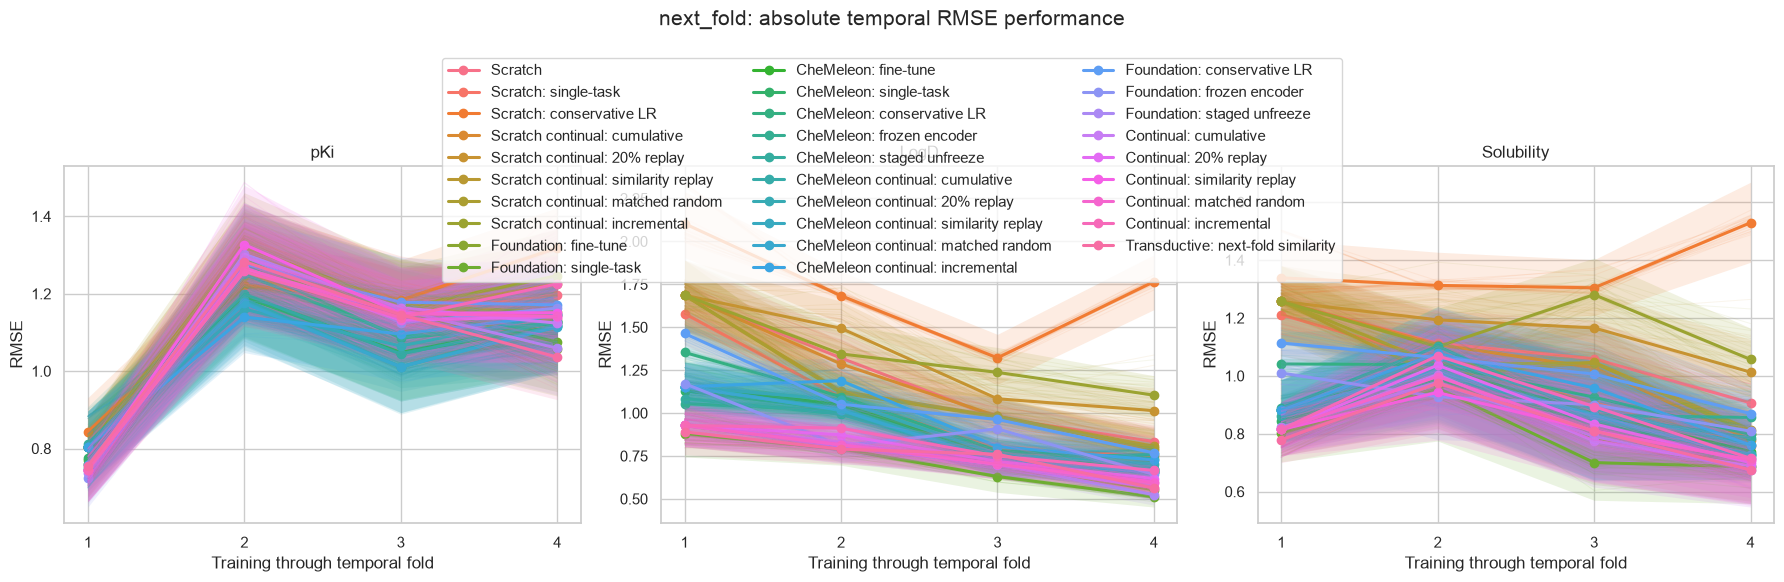

In [3]:
TEMPORAL_METRIC = "rmse"  # rmse, mae, or r2 have bootstrap intervals

def temporal_performance(scope, metric=TEMPORAL_METRIC):
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(18, 5), sharex=True)
    for ax, target in zip(axes, TARGETS):
        raw = full_metrics.query("evaluation_scope == @scope and target == @target")
        summary = bootstrap_summary.query(
            "evaluation_scope == @scope and target == @target and metric == @metric"
        )
        for strategy in STRATEGIES:
            subset = raw[raw.strategy == strategy]
            for _, replicate in subset.groupby("replicate_id"):
                ax.plot(replicate.origin, replicate[metric], color=PALETTE[strategy], alpha=.09, lw=.7)
            line = summary[summary.strategy == strategy].sort_values("origin")
            ax.plot(line.origin, line.estimate, marker="o", lw=2.2,
                    color=PALETTE[strategy], label=STRATEGY_LABEL[strategy])
            ax.fill_between(line.origin, line.ci_low, line.ci_high,
                            color=PALETTE[strategy], alpha=.14, linewidth=0)
        ax.set_title(TARGET_LABEL[target])
        ax.set_xlabel("Training through temporal fold")
        ax.set_ylabel(metric.upper())
        ax.set_xticks(sorted(raw.origin.unique()))
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=3, loc="upper center", bbox_to_anchor=(.5, 1.08))
    fig.suptitle(f"{scope}: absolute temporal {metric.upper()} performance", y=1.16, fontsize=15)
    fig.tight_layout()
    plt.show()

temporal_performance("next_fold")


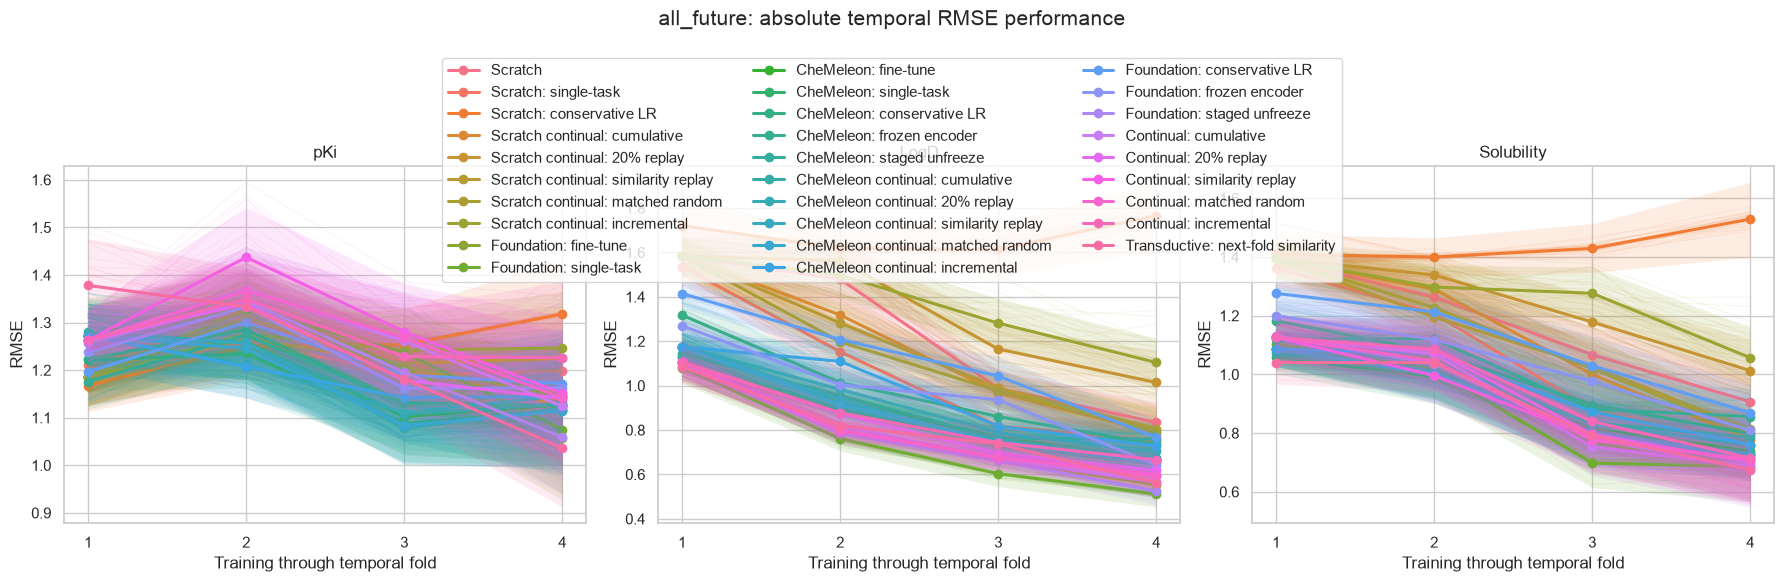

In [4]:
temporal_performance("all_future")


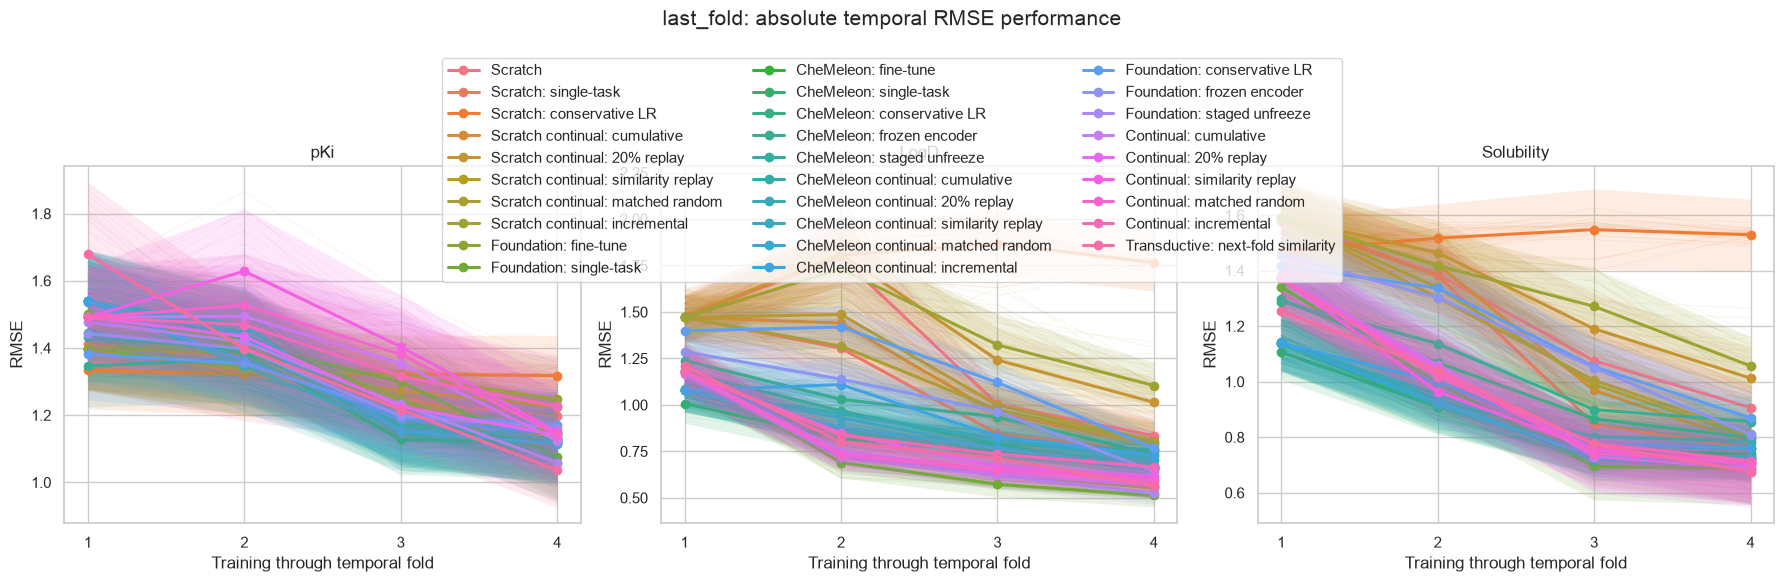

In [5]:
temporal_performance("last_fold")


## 2. Federation benefit relative to scratch

Positive values always favour the federation-derived strategy. For RMSE/MAE this is `(scratch − strategy) / |scratch| × 100`; for R² the sign is reversed. Dots show the matched full-test replicate effects. Lines and 95% ribbons use paired bootstrap draws, so both sides of every comparison share the same test rows and seed resampling.


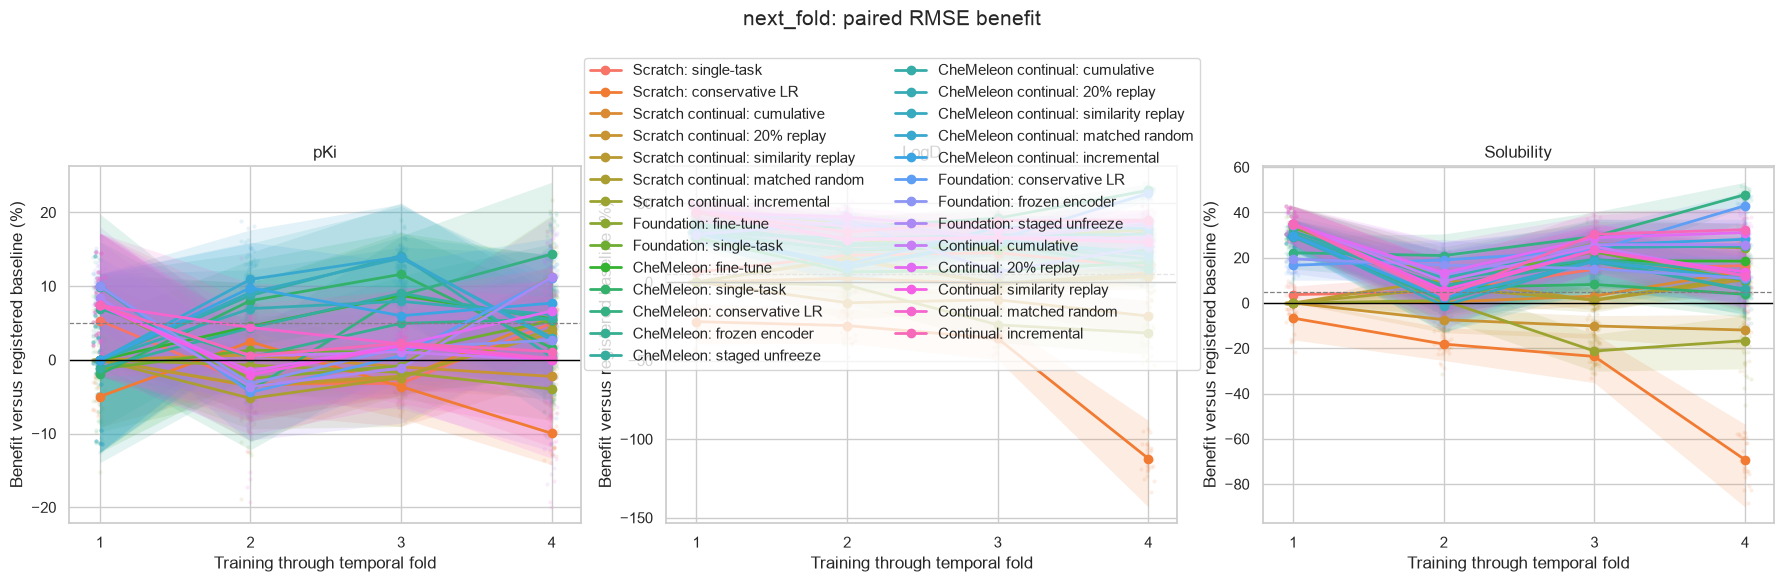

In [6]:
DELTA_METRIC = "rmse"

def paired_replicate_benefits(scope, target, metric):
    data = full_metrics.query("evaluation_scope == @scope and target == @target")
    index = ["origin", "replicate_id"]
    wide = data.pivot(index=index, columns="strategy", values=metric).reset_index()
    frames = []
    for strategy, comparator in STRATEGY_COMPARATOR.items():
        if strategy not in wide or comparator not in wide:
            continue
        raw = wide[comparator] - wide[strategy] if metric in LOWER_IS_BETTER else wide[strategy] - wide[comparator]
        frame = wide[index].copy()
        frame["strategy"] = strategy
        frame["baseline_strategy"] = comparator
        frame["relative_benefit_percent"] = 100 * raw / wide[comparator].abs().clip(lower=np.finfo(float).eps)
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

def temporal_delta(scope, metric=DELTA_METRIC):
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(18, 5), sharex=True, sharey=False)
    for ax, target in zip(axes, TARGETS):
        observed = paired_replicate_benefits(scope, target, metric)
        interval = pairwise_bootstrap.query(
            "evaluation_scope == @scope and target == @target and metric == @metric"
        )
        for strategy in [s for s in STRATEGY_COMPARATOR if s not in TRANSDUCTIVE_STRATEGIES]:
            dots = observed[observed.strategy == strategy]
            jitter = np.random.default_rng(7).normal(0, .025, len(dots))
            ax.scatter(dots.origin + jitter, dots.relative_benefit_percent, s=9,
                       color=PALETTE[strategy], alpha=.12, linewidth=0)
            line = interval[interval.strategy == strategy].sort_values("origin")
            ax.plot(line.origin, line.relative_benefit_percent, marker="o", lw=2,
                    color=PALETTE[strategy], label=STRATEGY_LABEL[strategy])
            ax.fill_between(line.origin, line.relative_ci_low, line.relative_ci_high,
                            color=PALETTE[strategy], alpha=.14, linewidth=0)
        ax.axhline(0, color="black", lw=1)
        ax.axhline(manifest["practical_threshold_percent"], color="grey", ls="--", lw=.9)
        ax.set_title(TARGET_LABEL[target])
        ax.set_xlabel("Training through temporal fold")
        ax.set_ylabel("Benefit versus registered baseline (%)")
        ax.set_xticks(sorted(observed.origin.unique()))
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2, loc="upper center", bbox_to_anchor=(.5, 1.08))
    fig.suptitle(f"{scope}: paired {metric.upper()} benefit", y=1.16, fontsize=15)
    fig.tight_layout()
    plt.show()

temporal_delta("next_fold")


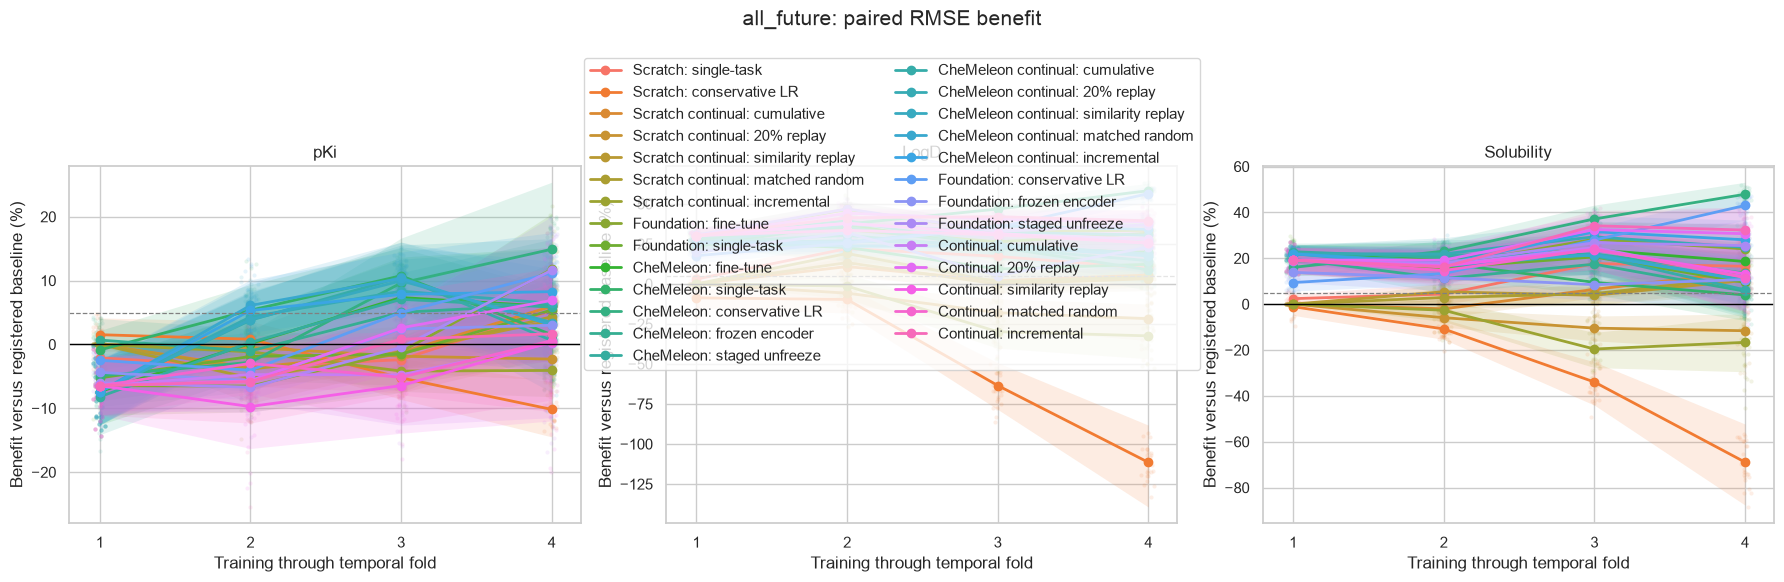

In [7]:
temporal_delta("all_future")


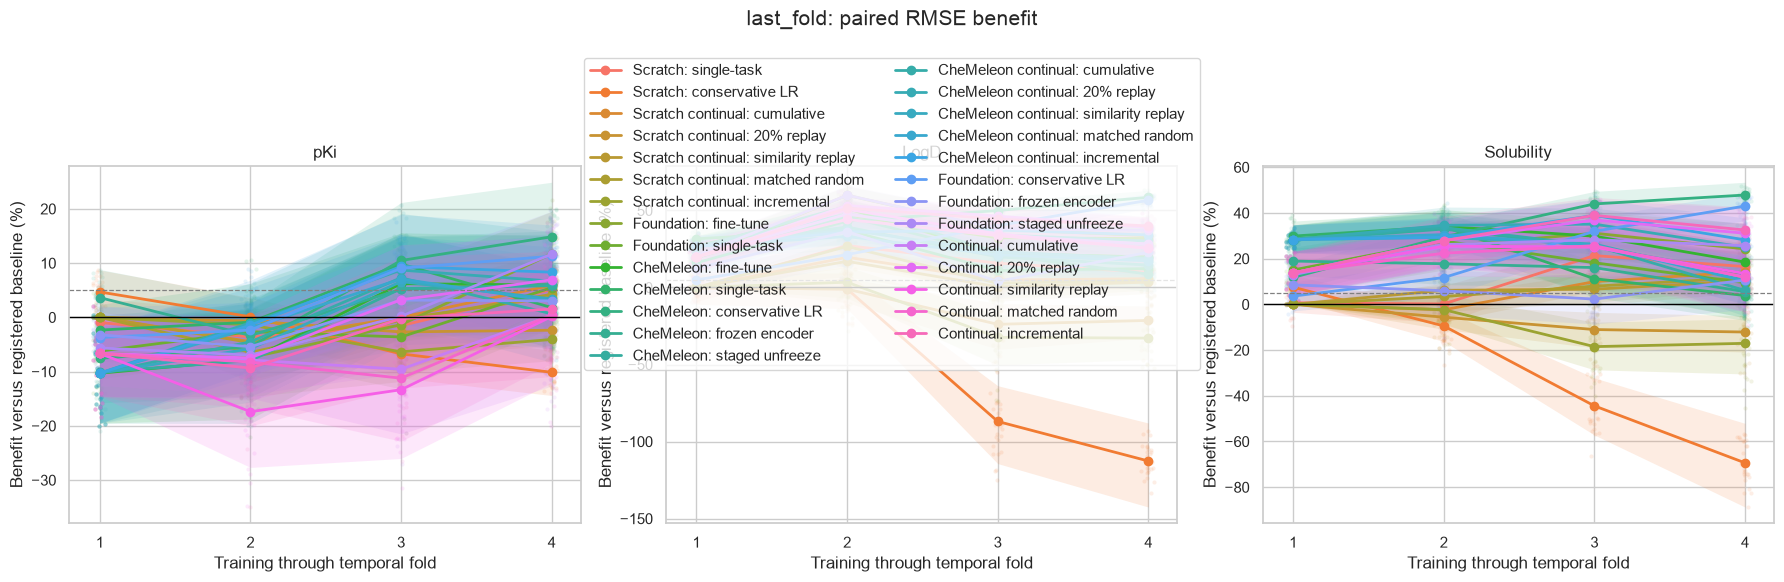

In [8]:
temporal_delta("last_fold")


## 3. Predicted-versus-observed parity

Choose one evaluation scope and rolling origin. Use `"mean"` to average predictions across all 25 fits or supply a replicate ID such as `"data_42__torch_1001"`. Rows are endpoints and columns are modelling strategies. The annotation gives the selected strategy’s mean full-test metric with its joint bootstrap 95% interval.


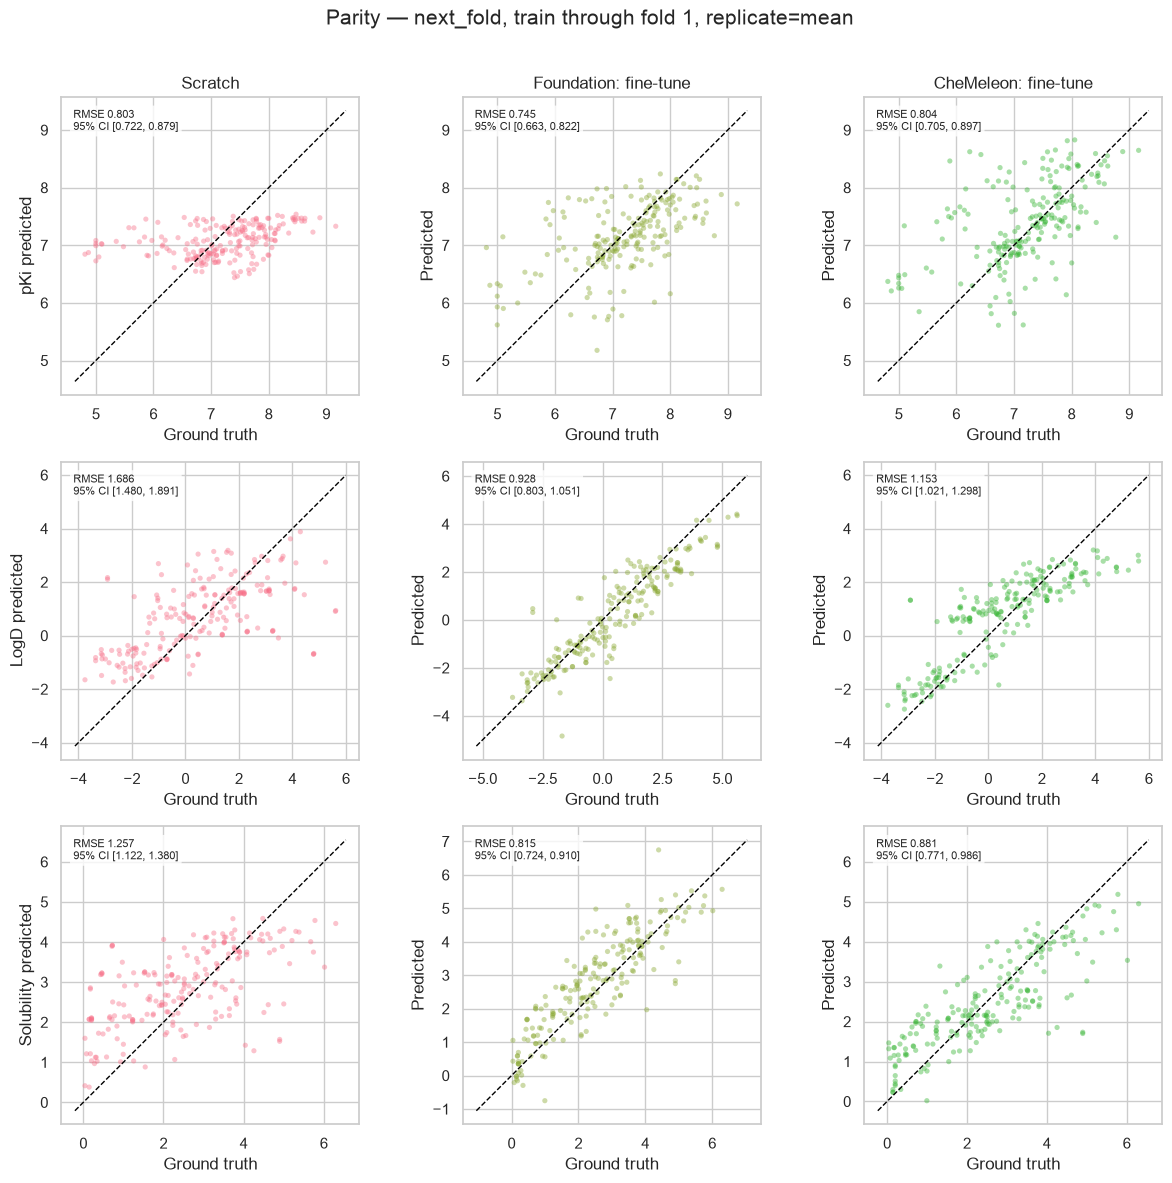

In [9]:
PARITY_SCOPE = "next_fold"       # next_fold | all_future | last_fold
PARITY_ORIGIN = 1                 # 1..4
PARITY_REPLICATE = "mean"        # mean | data_42__torch_1001 | ...
PARITY_STRATEGIES = [             # representative defaults; replace with any STRATEGIES subset
    strategy for strategy in ("scratch", "foundation_finetune", "chemeleon_finetune")
    if strategy in STRATEGIES
]
PARITY_METRIC = "rmse"

def parity_plot(scope, origin, replicate="mean", strategies=PARITY_STRATEGIES, metric=PARITY_METRIC):
    data = points.query("evaluation_scope == @scope and origin == @origin")
    fig, axes = plt.subplots(len(TARGETS), len(strategies),
                             figsize=(4.1 * len(strategies), 3.9 * len(TARGETS)), squeeze=False)
    for row, target in enumerate(TARGETS):
        for col, strategy in enumerate(strategies):
            ax = axes[row, col]
            subset = data[data.strategy == strategy]
            if replicate == "mean":
                plotted = subset.groupby("_row_id", as_index=False).agg(
                    actual=(f"{target}__actual", "first"), predicted=(f"{target}__predicted", "mean")
                )
            else:
                plotted = subset[subset.replicate_id == replicate].rename(
                    columns={f"{target}__actual": "actual", f"{target}__predicted": "predicted"}
                )[["_row_id", "actual", "predicted"]]
            lo = min(plotted.actual.min(), plotted.predicted.min())
            hi = max(plotted.actual.max(), plotted.predicted.max())
            pad = .04 * (hi - lo or 1)
            ax.scatter(plotted.actual, plotted.predicted, s=14, alpha=.42,
                       color=PALETTE[strategy], edgecolor="none")
            ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], color="black", ls="--", lw=1)
            interval = bootstrap_summary.query(
                "origin == @origin and evaluation_scope == @scope and target == @target "
                "and strategy == @strategy and metric == @metric"
            ).iloc[0]
            ax.text(.04, .96, f"{metric.upper()} {interval.estimate:.3f}\n95% CI [{interval.ci_low:.3f}, {interval.ci_high:.3f}]",
                    transform=ax.transAxes, va="top", fontsize=8,
                    bbox=dict(boxstyle="round", facecolor="white", alpha=.8, edgecolor="none"))
            if row == 0:
                ax.set_title(STRATEGY_LABEL[strategy])
            if col == 0:
                ax.set_ylabel(f"{TARGET_LABEL[target]} predicted")
            else:
                ax.set_ylabel("Predicted")
            ax.set_xlabel("Ground truth")
            ax.set_aspect("equal", adjustable="box")
    fig.suptitle(f"Parity — {scope}, train through fold {origin}, replicate={replicate}", y=1.01, fontsize=15)
    fig.tight_layout()
    plt.show()

parity_plot(PARITY_SCOPE, PARITY_ORIGIN, PARITY_REPLICATE)


## 4. Where on the endpoint scale does federation help?

Select one strategy, scope, and origin. Each point is a compound’s mean paired relative absolute-error improvement over scratch across the 25 fits. Positive means the federation-derived strategy is better. The solid trend is the median within ground-truth quantile bins; the ribbon is a paired full-size bootstrap interval over rows and matched replicates.

Relative effects can become very large when scratch error is almost zero. The plot clips only its visual y-axis to the 1st–99th percentiles; calculations and the zero line remain unchanged.


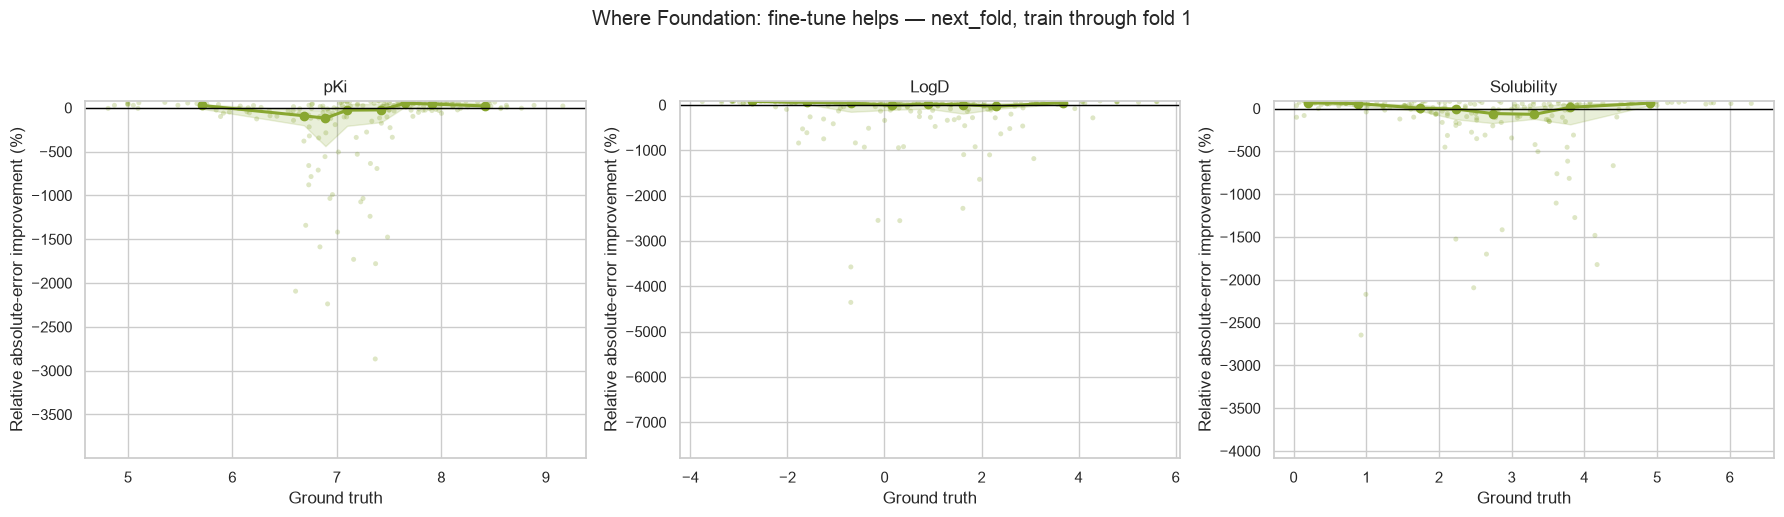

In [10]:
SCALE_SCOPE = "next_fold"
SCALE_ORIGIN = 1
SCALE_STRATEGY = "foundation_finetune"  # any non-scratch strategy
SCALE_BINS = 8
SCALE_BOOTSTRAPS = 1000

def scale_improvement(scope, origin, strategy, bins=8, n_bootstrap=1000):
    base = points.query("evaluation_scope == @scope and origin == @origin")
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(18, 5))
    rng = np.random.default_rng(9182)
    for ax, target in zip(axes, TARGETS):
        scratch = base[base.strategy == "scratch"][
            ["_row_id", "replicate_id", f"{target}__actual", f"{target}__predicted"]
        ].rename(columns={f"{target}__actual": "actual", f"{target}__predicted": "scratch_pred"})
        fed = base[base.strategy == strategy][["_row_id", "replicate_id", f"{target}__predicted"]].rename(
            columns={f"{target}__predicted": "strategy_pred"}
        )
        paired = scratch.merge(fed, on=["_row_id", "replicate_id"], validate="one_to_one")
        scratch_error = np.abs(paired.scratch_pred - paired.actual)
        strategy_error = np.abs(paired.strategy_pred - paired.actual)
        paired["relative_improvement"] = 100 * (scratch_error - strategy_error) / scratch_error.clip(lower=1e-8)
        compound = paired.groupby("_row_id", as_index=False).agg(
            actual=("actual", "first"), relative_improvement=("relative_improvement", "mean")
        )
        compound["bin"] = pd.qcut(compound.actual, q=min(bins, compound.actual.nunique()), duplicates="drop")
        centers = compound.groupby("bin", observed=True).actual.median().to_numpy()
        central = compound.groupby("bin", observed=True).relative_improvement.median().to_numpy()
        boot_lines = []
        row_ids = paired._row_id.unique()
        replicate_ids = paired.replicate_id.unique()
        for _ in range(n_bootstrap):
            sampled_rows = pd.DataFrame({"_row_id": rng.choice(row_ids, len(row_ids), replace=True),
                                         "_row_draw": np.arange(len(row_ids))})
            sampled_reps = pd.DataFrame({"replicate_id": rng.choice(replicate_ids, len(replicate_ids), replace=True),
                                         "_replicate_draw": np.arange(len(replicate_ids))})
            sampled = sampled_rows.merge(paired, on="_row_id").merge(sampled_reps, on="replicate_id")
            sampled_s = np.abs(sampled.scratch_pred - sampled.actual)
            sampled["relative_improvement"] = 100 * (sampled_s - np.abs(sampled.strategy_pred-sampled.actual)) / sampled_s.clip(lower=1e-8)
            per_row = sampled.groupby("_row_draw", as_index=False).agg(
                actual=("actual", "first"), relative_improvement=("relative_improvement", "mean")
            )
            per_row["bin"] = pd.cut(per_row.actual, bins=[interval.left for interval in compound.bin.cat.categories] + [compound.bin.cat.categories[-1].right], include_lowest=True)
            boot_lines.append(per_row.groupby("bin", observed=False).relative_improvement.median().to_numpy())
        boot_lines = np.asarray(boot_lines, dtype=float)
        ax.scatter(compound.actual, compound.relative_improvement, s=13, alpha=.28,
                   color=PALETTE[strategy], edgecolor="none")
        ax.plot(centers, central, marker="o", lw=2.2, color=PALETTE[strategy])
        ax.fill_between(centers, np.nanquantile(boot_lines, .025, axis=0),
                        np.nanquantile(boot_lines, .975, axis=0), color=PALETTE[strategy], alpha=.18)
        ax.axhline(0, color="black", lw=1)
        limits = np.nanquantile(compound.relative_improvement, [.01, .99])
        if np.isfinite(limits).all() and limits[0] < limits[1]:
            ax.set_ylim(limits)
        ax.set_title(TARGET_LABEL[target])
        ax.set_xlabel("Ground truth")
        ax.set_ylabel("Relative absolute-error improvement (%)")
    fig.suptitle(f"Where {STRATEGY_LABEL[strategy]} helps — {scope}, train through fold {origin}", y=1.03)
    fig.tight_layout()
    plt.show()

scale_improvement(SCALE_SCOPE, SCALE_ORIGIN, SCALE_STRATEGY, SCALE_BINS, SCALE_BOOTSTRAPS)


## 5. Headline result for each evaluation scenario

These forest plots summarize equal-weight performance across all four rolling-origin challenges. The point is mean relative RMSE benefit over each strategy’s registered, formulation-matched scratch baseline; bars are paired-bootstrap 95% intervals. The dashed vertical line marks the configurable 5% practical-improvement threshold. `next_fold` is the primary claim; the other two plots are sensitivity analyses because their compounds overlap across origins.


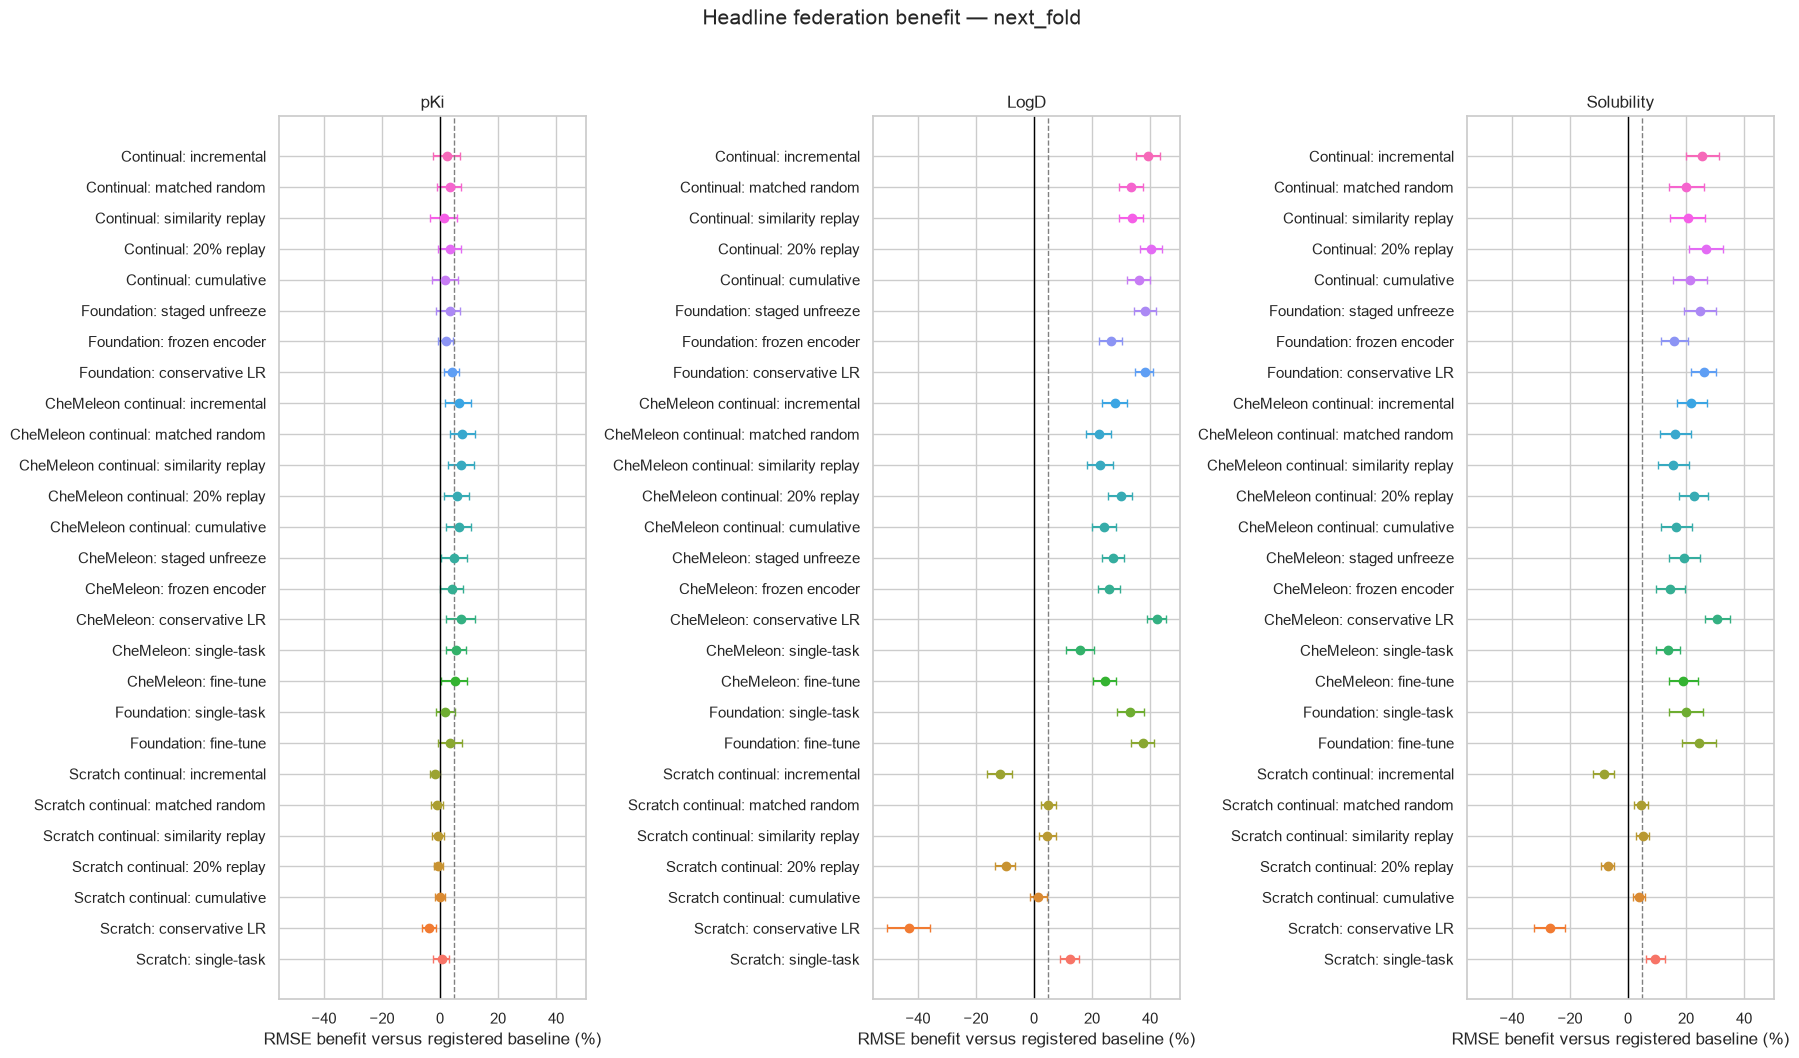

,endpoint,strategy,relative_benefit_percent,relative_ci_low,relative_ci_high,p_adjusted,conclusion
105,LogD,chemeleon_conservative_lr,42.3,38.9,45.5,4.61e-82,statistically and practically better
213,LogD,continual_replay,40.3,36.5,44.0,7.47e-216,statistically and practically better
240,LogD,continual_incremental,39.2,35.0,43.2,1.2e-197,statistically and practically better
195,LogD,foundation_staged_unfreeze,38.3,34.4,42.1,6.5e-237,statistically and practically better
177,LogD,foundation_conservative_lr,38.2,34.9,41.1,1.43e-65,statistically and practically better
69,LogD,foundation_finetune,37.6,33.6,41.5,8.41e-225,statistically and practically better
204,LogD,continual_cumulative,36.1,32.0,39.9,1.97e-209,statistically and practically better
222,LogD,continual_similarity_replay,33.6,29.5,37.7,1.97e-186,statistically and practically better
231,LogD,continual_similarity_matched_random,33.5,29.4,37.5,1.97e-186,statistically and practically better
78,LogD,foundation_finetune_single_task,33.2,28.7,38.0,2e-14,statistically and practically better


In [11]:
def headline(scope):
    data = global_significance.query("evaluation_scope == @scope and metric == 'rmse'").copy()
    data = data[~data.strategy.isin(TRANSDUCTIVE_STRATEGIES)]
    data["endpoint"] = data.target.map(TARGET_LABEL)
    strategies = [s for s in STRATEGY_COMPARATOR if s not in TRANSDUCTIVE_STRATEGIES]
    fig, axes = plt.subplots(
        1, len(TARGETS), figsize=(18, max(6, .38 * len(strategies))), sharex=True
    )
    for ax, target in zip(axes, TARGETS):
        subset = data[data.target == target].set_index("strategy").loc[strategies].reset_index()
        y = np.arange(len(subset))
        x = subset.relative_benefit_percent.to_numpy()
        low = x - subset.relative_ci_low.to_numpy()
        high = subset.relative_ci_high.to_numpy() - x
        colors = [PALETTE[s] for s in subset.strategy]
        for yi, xi, lo, hi, color in zip(y, x, low, high, colors):
            ax.errorbar(xi, yi, xerr=np.array([[lo], [hi]]), fmt="o", color=color, capsize=3)
        ax.axvline(0, color="black", lw=1)
        ax.axvline(manifest["practical_threshold_percent"], color="grey", ls="--", lw=1)
        ax.set_yticks(y, [STRATEGY_LABEL[s] for s in subset.strategy])
        ax.set_title(TARGET_LABEL[target])
        ax.set_xlabel("RMSE benefit versus registered baseline (%)")
    fig.suptitle(f"Headline federation benefit — {scope}", y=1.03, fontsize=15)
    fig.tight_layout()
    plt.show()
    display(data[["endpoint", "strategy", "relative_benefit_percent", "relative_ci_low",
                  "relative_ci_high", "p_adjusted", "conclusion"]]
            .sort_values(["endpoint", "relative_benefit_percent"], ascending=[True, False])
            .style.format({"relative_benefit_percent": "{:.1f}", "relative_ci_low": "{:.1f}",
                           "relative_ci_high": "{:.1f}", "p_adjusted": "{:.3g}"}))

headline("next_fold")


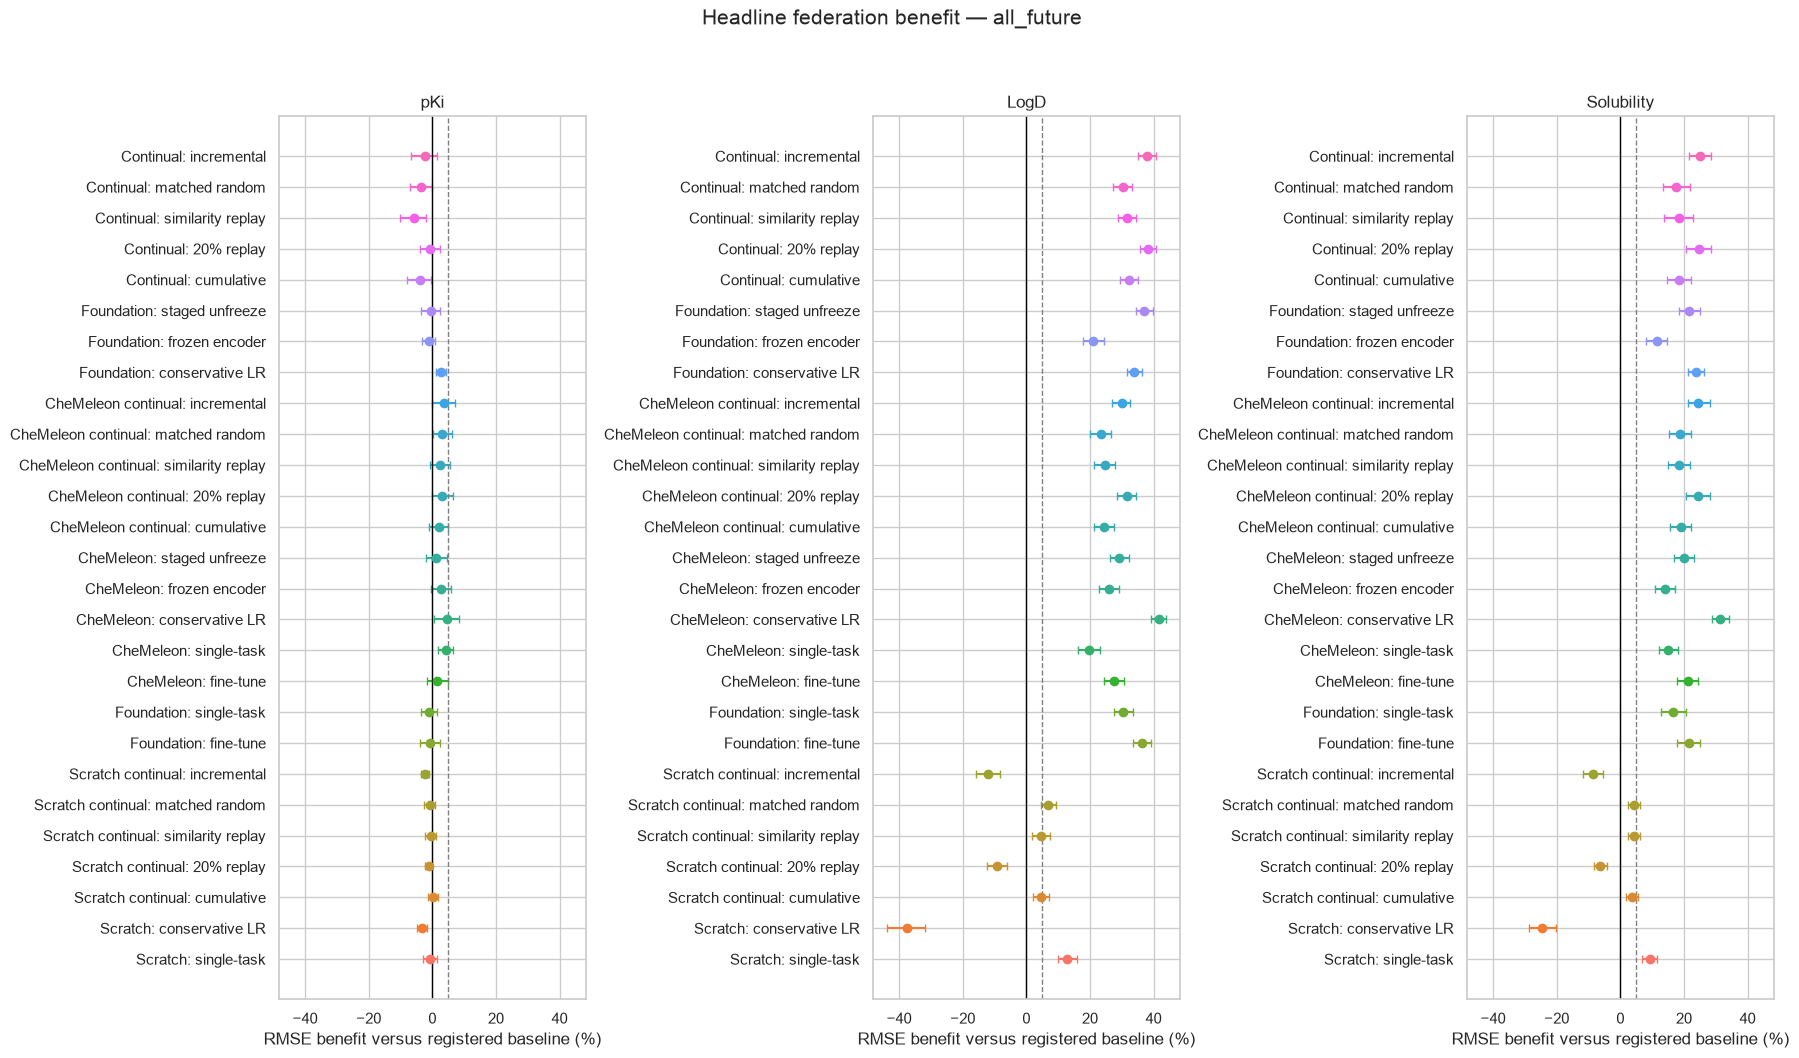

,endpoint,strategy,relative_benefit_percent,relative_ci_low,relative_ci_high,p_adjusted,conclusion
99,LogD,chemeleon_conservative_lr,41.6,39.2,43.9,3.94e-93,statistically and practically better
207,LogD,continual_replay,38.2,35.7,40.8,7.43e-213,statistically and practically better
234,LogD,continual_incremental,37.9,35.1,40.7,1.54e-203,statistically and practically better
189,LogD,foundation_staged_unfreeze,37.1,34.3,39.9,6.9e-252,statistically and practically better
63,LogD,foundation_finetune,36.2,33.4,39.1,6.28e-242,statistically and practically better
171,LogD,foundation_conservative_lr,34.0,31.7,36.2,1.82e-64,statistically and practically better
198,LogD,continual_cumulative,32.2,29.4,35.1,6.43e-211,statistically and practically better
216,LogD,continual_similarity_replay,31.8,28.9,34.6,1.54e-200,statistically and practically better
135,LogD,chemeleon_continual_replay,31.5,28.7,34.4,9.95e-120,statistically and practically better
72,LogD,foundation_finetune_single_task,30.5,27.5,33.6,1.53e-121,statistically and practically better


In [12]:
headline("all_future")


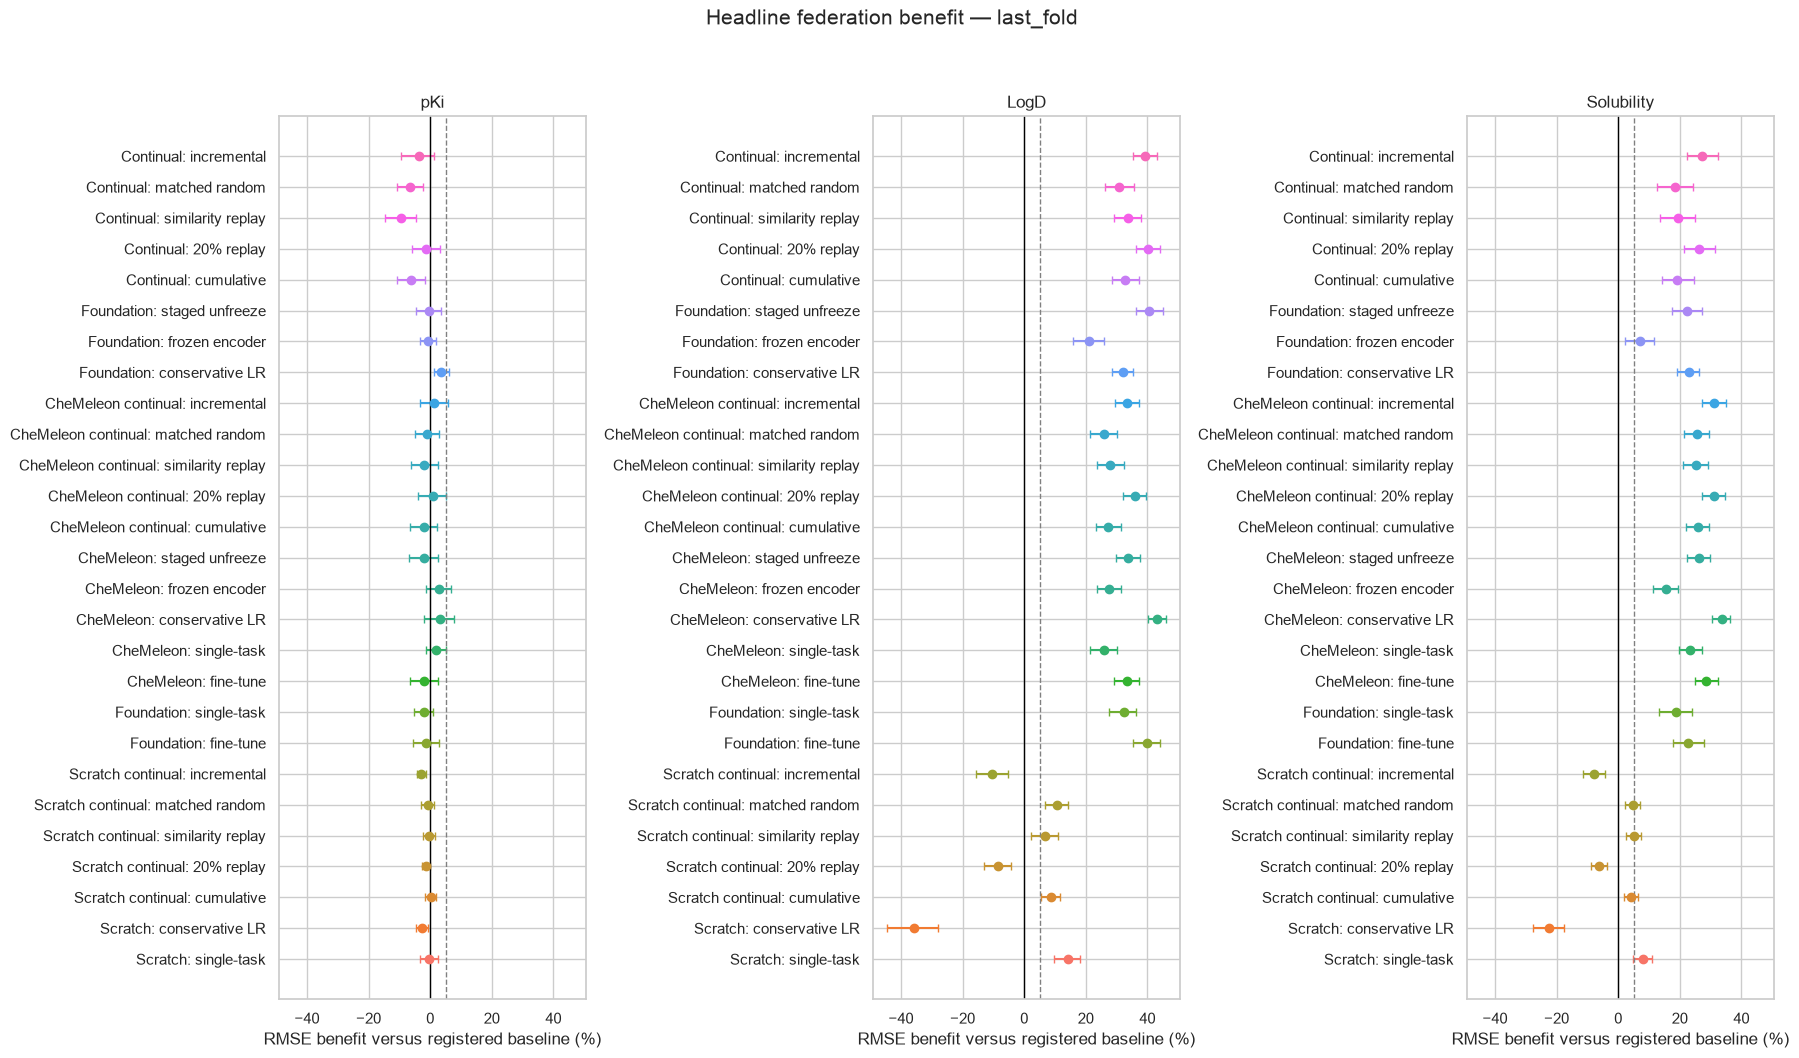

,endpoint,strategy,relative_benefit_percent,relative_ci_low,relative_ci_high,p_adjusted,conclusion
102,LogD,chemeleon_conservative_lr,43.1,40.1,46.0,5.43e-70,statistically and practically better
192,LogD,foundation_staged_unfreeze,40.6,36.4,45.2,9.99e-201,statistically and practically better
210,LogD,continual_replay,40.2,36.4,44.0,7.7e-155,statistically and practically better
66,LogD,foundation_finetune,39.7,35.4,44.1,1.33e-191,statistically and practically better
237,LogD,continual_incremental,39.3,35.3,43.1,6.29e-128,statistically and practically better
138,LogD,chemeleon_continual_replay,35.9,32.1,39.6,7.39e-94,statistically and practically better
120,LogD,chemeleon_staged_unfreeze,33.7,29.9,37.5,5.3e-118,statistically and practically better
219,LogD,continual_similarity_replay,33.6,29.1,37.9,1.28e-152,statistically and practically better
165,LogD,chemeleon_continual_incremental,33.5,29.6,37.3,2.06e-72,statistically and practically better
84,LogD,chemeleon_finetune,33.3,29.3,37.3,1.16e-114,statistically and practically better


In [13]:
headline("last_fold")


## 6. Statistical distinctness and practical significance

The workflow follows the supplied method-comparison paper:

1. Treat each rolling origin as its own modelling challenge.
2. Run a repeated-measures ANOVA across the 25 matched full-test fits, followed by repeated-measures Tukey HSD.
3. When residual normality is strongly violated (`p < 0.001`) or the variance ratio exceeds 9, use Friedman followed by Conover–Friedman pairwise tests with Holm correction.
4. Report paired effect sizes and paired-bootstrap 95% intervals.
5. Call federation practically better only when the full 95% relative-RMSE interval clears the configured 5% threshold.

Change the selectors below to inspect each endpoint, scope, metric, and origin. No endpoint or evaluation scope is pooled with another.


,origin,strategy,relative_benefit_percent,relative_ci_low,relative_ci_high,probability_better,test,p_adjusted,conclusion
692,1,foundation_conservative_lr,10.1,5.8,13.9,1.000,Conover_Friedman_Holm,3.65e-30,statistically and practically better
728,1,foundation_frozen,10.0,4.1,16.0,1.000,Conover_Friedman_Holm,3.93e-32,statistically better; practical threshold not established
404,1,chemeleon_conservative_lr,9.9,-1.0,19.8,0.964,Conover_Friedman_Holm,2.49e-31,fixed-test difference favours federation; joint bootstrap includes zero
764,1,foundation_staged_unfreeze,8.3,-0.7,18.1,0.962,Conover_Friedman_Holm,7.11e-23,fixed-test difference favours federation; joint bootstrap includes zero
260,1,foundation_finetune,7.4,-2.1,17.2,0.939,Conover_Friedman_Holm,4.66e-14,fixed-test difference favours federation; joint bootstrap includes zero
800,1,continual_cumulative,7.4,-2.1,17.2,0.939,Conover_Friedman_Holm,4.66e-14,fixed-test difference favours federation; joint bootstrap includes zero
836,1,continual_replay,7.4,-2.1,17.2,0.939,Conover_Friedman_Holm,4.66e-14,fixed-test difference favours federation; joint bootstrap includes zero
872,1,continual_similarity_replay,7.4,-2.1,17.2,0.939,Conover_Friedman_Holm,4.66e-14,fixed-test difference favours federation; joint bootstrap includes zero
908,1,continual_similarity_matched_random,7.4,-2.1,17.2,0.939,Conover_Friedman_Holm,4.66e-14,fixed-test difference favours federation; joint bootstrap includes zero
944,1,continual_incremental,7.4,-2.1,17.2,0.939,Conover_Friedman_Holm,4.66e-14,fixed-test difference favours federation; joint bootstrap includes zero


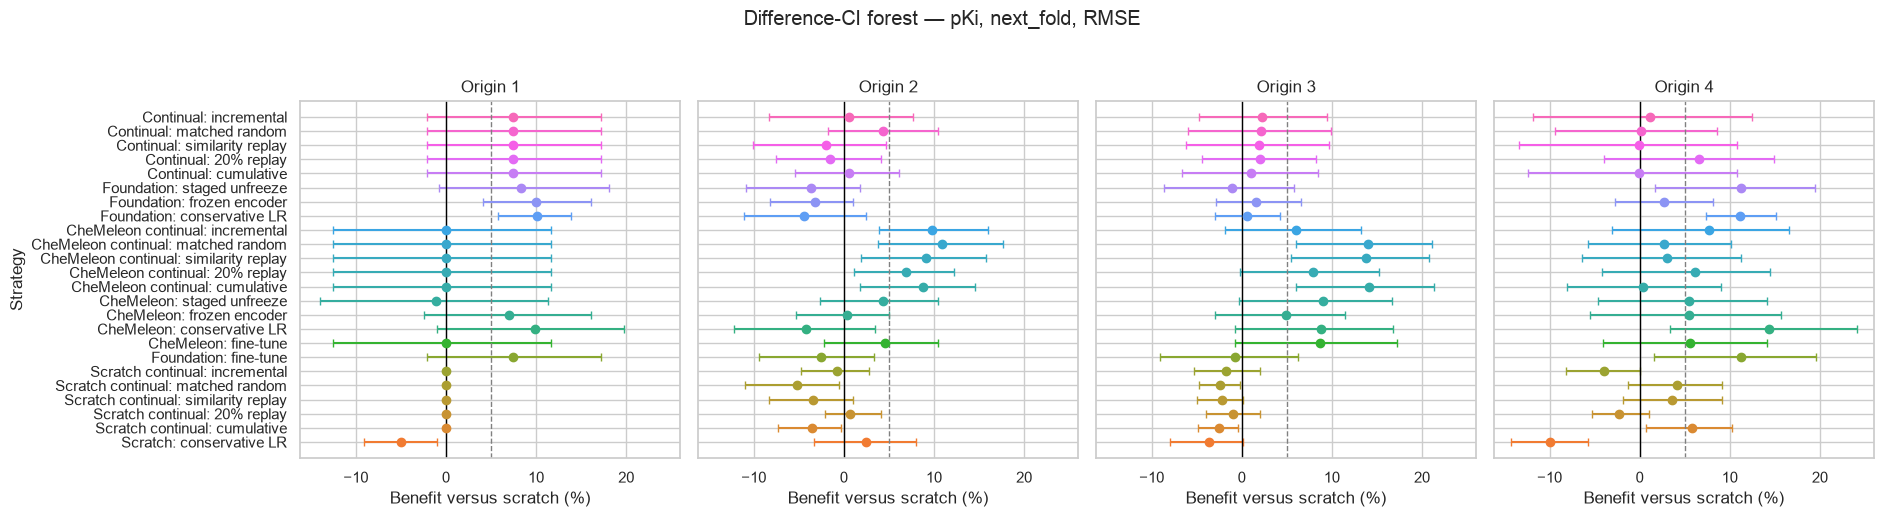

In [14]:
SIG_SCOPE = "next_fold"
SIG_TARGET = TARGETS[0]
SIG_METRIC = "rmse"
SIG_ORIGIN = 1
SIG_FAMILY = "prospective_multitask"

selected = significance.query(
    "evaluation_scope == @SIG_SCOPE and target == @SIG_TARGET and metric == @SIG_METRIC "
    "and comparison_family == @SIG_FAMILY"
).copy()
display(selected[["origin", "strategy", "relative_benefit_percent", "relative_ci_low",
                  "relative_ci_high", "probability_better", "test", "p_adjusted", "conclusion"]]
        .sort_values(["origin", "relative_benefit_percent"], ascending=[True, False])
        .style.format({"relative_benefit_percent": "{:.1f}", "relative_ci_low": "{:.1f}",
                       "relative_ci_high": "{:.1f}", "probability_better": "{:.3f}",
                       "p_adjusted": "{:.3g}"}))

fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=True, sharey=True)
strategies = [s for s in STRATEGIES if s in set(selected.strategy)]
for ax, origin in zip(axes, sorted(selected.origin.unique())):
    subset = selected[selected.origin == origin].set_index("strategy").loc[strategies].reset_index()
    y = np.arange(len(subset))
    for yi, row in subset.iterrows():
        ax.errorbar(row.relative_benefit_percent, yi,
                    xerr=[[row.relative_benefit_percent-row.relative_ci_low],
                          [row.relative_ci_high-row.relative_benefit_percent]],
                    fmt="o", color=PALETTE[row.strategy], capsize=3)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(manifest["practical_threshold_percent"], color="grey", ls="--", lw=1)
    ax.set_title(f"Origin {origin}")
    ax.set_yticks(y, [STRATEGY_LABEL[s] for s in subset.strategy])
    ax.set_xlabel("Benefit versus scratch (%)")
axes[0].set_ylabel("Strategy")
fig.suptitle(f"Difference-CI forest — {TARGET_LABEL[SIG_TARGET]}, {SIG_SCOPE}, {SIG_METRIC.upper()}", y=1.03)
fig.tight_layout()
plt.show()


### MCSim-style method comparison

The following compact view places all strategies on the same performance axis for one modelling challenge. Points are the 25-fit means, bars are paired-bootstrap 95% intervals, and the best observed method is marked. Read this together with the adjusted pairwise table beneath it; overlapping marginal intervals are not themselves a hypothesis test.


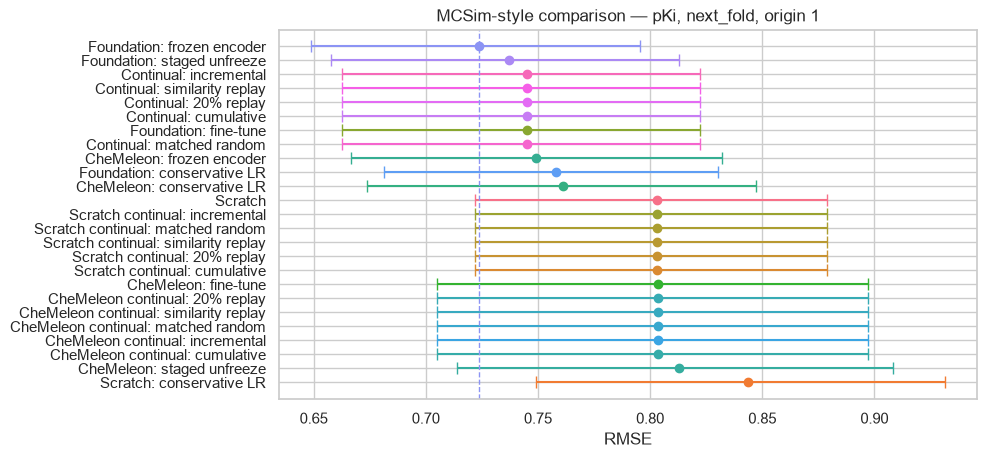

,method_a,method_b,test,mean_a_minus_b,effect_size_dz,p_adjusted
102626,foundation_frozen,scratch_conservative_lr,Conover_Friedman_Holm,-0.1201,-5.605,7.94e-57
102633,foundation_staged_unfreeze,scratch_conservative_lr,Conover_Friedman_Holm,-0.1063,-3.460,6.93e-46
102518,chemeleon_frozen,scratch_conservative_lr,Conover_Friedman_Holm,-0.0945,-4.598,2.71e-40
102531,chemeleon_staged_unfreeze,foundation_frozen,Conover_Friedman_Holm,0.0894,1.849,1.7e-35
102588,continual_similarity_matched_random,scratch_conservative_lr,Conover_Friedman_Holm,-0.0984,-3.027,1.63e-34
102599,continual_similarity_replay,scratch_conservative_lr,Conover_Friedman_Holm,-0.0984,-3.027,1.63e-34
102576,continual_replay,scratch_conservative_lr,Conover_Friedman_Holm,-0.0984,-3.027,1.63e-34
102549,continual_cumulative,scratch_conservative_lr,Conover_Friedman_Holm,-0.0984,-3.027,1.63e-34
102618,foundation_finetune,scratch_conservative_lr,Conover_Friedman_Holm,-0.0984,-3.027,1.63e-34
102563,continual_incremental,scratch_conservative_lr,Conover_Friedman_Holm,-0.0984,-3.027,1.63e-34


In [15]:
def mcsim_view(scope, target, metric, origin):
    family_strategies = manifest.get("strategy_families", {}).get(SIG_FAMILY, STRATEGIES)
    summary = bootstrap_summary.query(
        "evaluation_scope == @scope and target == @target and metric == @metric and origin == @origin"
    ).set_index("strategy").loc[family_strategies].reset_index()
    ascending = metric in LOWER_IS_BETTER
    summary = summary.sort_values("estimate", ascending=ascending).reset_index(drop=True)
    y = np.arange(len(summary))
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for yi, row in summary.iterrows():
        ax.errorbar(row.estimate, yi,
                    xerr=[[row.estimate-row.ci_low], [row.ci_high-row.estimate]],
                    fmt="o", capsize=4, color=PALETTE[row.strategy])
    ax.axvline(summary.iloc[0].estimate, color=PALETTE[summary.iloc[0].strategy], ls="--", lw=1)
    ax.set_yticks(y, [STRATEGY_LABEL[s] for s in summary.strategy])
    ax.invert_yaxis()
    ax.set_xlabel(metric.upper())
    ax.set_title(f"MCSim-style comparison — {TARGET_LABEL[target]}, {scope}, origin {origin}")
    plt.show()
    tests = pairwise_tests.query(
        "analysis_level == 'per_origin' and evaluation_scope == @scope and target == @target "
        "and metric == @metric and origin_number == @origin and recommended == True "
        "and comparison_family == @SIG_FAMILY"
    )
    display(tests[["method_a", "method_b", "test", "mean_a_minus_b", "effect_size_dz", "p_adjusted"]]
            .sort_values("p_adjusted").style.format({"mean_a_minus_b": "{:.4f}",
                                                     "effect_size_dz": "{:.3f}",
                                                     "p_adjusted": "{:.3g}"}))

mcsim_view(SIG_SCOPE, SIG_TARGET, SIG_METRIC, SIG_ORIGIN)


### Diagnostics and omnibus decision

The Q–Q view is for the additive repeated-measures residuals. The table records both parametric and rank-based omnibus tests, the diagnostic rule, and which route was used for the reported pairwise conclusion.


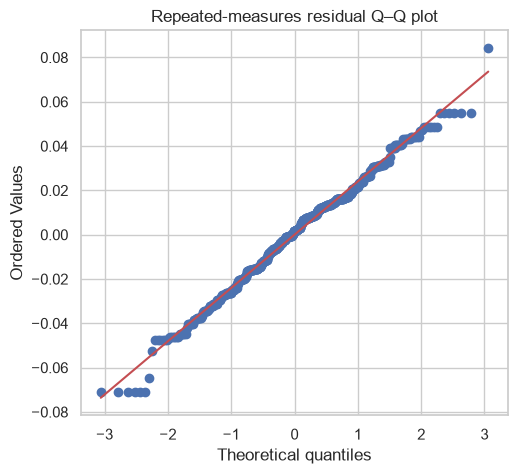

,test,statistic,p_value,partial_eta_squared,shapiro_residual_p,variance_ratio,parametric_assumptions_acceptable,recommended_test
270,repeated_measures_ANOVA,42.814,2.36e-111,0.641,0.00711,76.20,False,Friedman
271,Friedman,402.667,2.13e-70,nan,0.00711,76.20,False,Friedman


In [16]:
chosen_residuals = residuals.query(
    "analysis_level == 'per_origin' and evaluation_scope == @SIG_SCOPE and target == @SIG_TARGET "
    "and metric == @SIG_METRIC and origin_number == @SIG_ORIGIN "
    "and comparison_family == @SIG_FAMILY"
).residual.dropna()
fig, ax = plt.subplots(figsize=(5.5, 5))
stats.probplot(chosen_residuals, dist="norm", plot=ax)
ax.set_title("Repeated-measures residual Q–Q plot")
plt.show()

decision = omnibus.query(
    "analysis_level == 'per_origin' and evaluation_scope == @SIG_SCOPE and target == @SIG_TARGET "
    "and metric == @SIG_METRIC and origin_number == @SIG_ORIGIN "
    "and comparison_family == @SIG_FAMILY"
)
display(decision[["test", "statistic", "p_value", "partial_eta_squared",
                  "shapiro_residual_p", "variance_ratio",
                  "parametric_assumptions_acceptable", "recommended_test"]]
        .style.format({"statistic": "{:.3f}", "p_value": "{:.3g}",
                       "partial_eta_squared": "{:.3f}", "shapiro_residual_p": "{:.3g}",
                       "variance_ratio": "{:.2f}"}))


## 7. Exact values and claim boundary

The primary overall claim is the equal-weight result across the four `next_fold` challenges, separately for each endpoint and strategy. It is conditional on these observed temporal challenges. `all_future` and `last_fold` are sensitivity results, and a strategy-by-origin reversal should be described rather than hidden by the overall mean.


In [17]:
display(global_significance.query("metric == 'rmse'")
        [["evaluation_scope", "target", "strategy", "relative_benefit_percent",
          "relative_ci_low", "relative_ci_high", "probability_better",
          "p_adjusted", "conclusion"]]
        .sort_values(["evaluation_scope", "target", "relative_benefit_percent"],
                     ascending=[True, True, False])
        .style.format({"relative_benefit_percent": "{:.1f}", "relative_ci_low": "{:.1f}",
                       "relative_ci_high": "{:.1f}", "probability_better": "{:.3f}",
                       "p_adjusted": "{:.3g}"}))


,evaluation_scope,target,strategy,relative_benefit_percent,relative_ci_low,relative_ci_high,probability_better,p_adjusted,conclusion
99,all_future,LogD (pH 7.40),chemeleon_conservative_lr,41.6,39.2,43.9,1.000,3.94e-93,statistically and practically better
207,all_future,LogD (pH 7.40),continual_replay,38.2,35.7,40.8,1.000,7.43e-213,statistically and practically better
234,all_future,LogD (pH 7.40),continual_incremental,37.9,35.1,40.7,1.000,1.54e-203,statistically and practically better
189,all_future,LogD (pH 7.40),foundation_staged_unfreeze,37.1,34.3,39.9,1.000,6.9e-252,statistically and practically better
63,all_future,LogD (pH 7.40),foundation_finetune,36.2,33.4,39.1,1.000,6.28e-242,statistically and practically better
243,all_future,LogD (pH 7.40),transductive_similarity_filtered,34.4,31.0,37.7,1.000,0,statistically and practically better
171,all_future,LogD (pH 7.40),foundation_conservative_lr,34.0,31.7,36.2,1.000,1.82e-64,statistically and practically better
198,all_future,LogD (pH 7.40),continual_cumulative,32.2,29.4,35.1,1.000,6.43e-211,statistically and practically better
216,all_future,LogD (pH 7.40),continual_similarity_replay,31.8,28.9,34.6,1.000,1.54e-200,statistically and practically better
135,all_future,LogD (pH 7.40),chemeleon_continual_replay,31.5,28.7,34.4,1.000,9.95e-120,statistically and practically better


## 8. Multi-task versus fully separate endpoint models

This view compares three independent single-endpoint models with the corresponding multi-task model. Positive values mean that separating pKi, LogD, and solubility reduced RMSE. Scratch, supplied-foundation, and CheMeleon comparisons are kept separate so that task formulation is not confused with initialization.


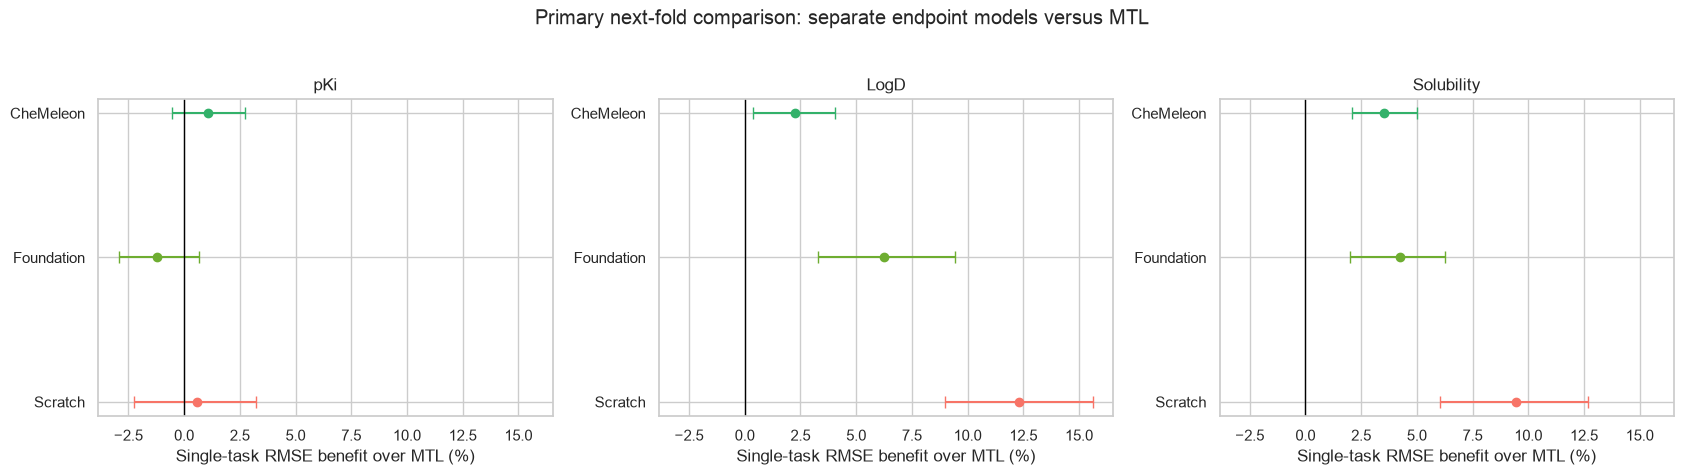

,endpoint,formulation,estimate,ci_low,ci_high
0,LogD,Scratch,+12.3,+9.0,+15.6
1,LogD,Foundation,+6.2,+3.3,+9.4
2,LogD,CheMeleon,+2.2,+0.4,+4.0
3,Solubility,Scratch,+9.4,+6.1,+12.7
4,Solubility,Foundation,+4.3,+2.0,+6.3
5,Solubility,CheMeleon,+3.5,+2.1,+5.0
6,pKi,Scratch,+0.6,-2.3,+3.2
7,pKi,Foundation,-1.2,-2.9,+0.7
8,pKi,CheMeleon,+1.1,-0.6,+2.7


In [18]:
required_single_task = {
    "scratch", "scratch_single_task", "foundation_finetune", "foundation_finetune_single_task",
    "chemeleon_finetune", "chemeleon_finetune_single_task"
}
if required_single_task.issubset(set(bootstrap_metrics.strategy)):
    task_boot = (
        bootstrap_metrics.query("evaluation_scope == 'next_fold'")
        .groupby(["target", "strategy", "bootstrap_draw"], as_index=False).rmse.mean()
        .pivot(index=["target", "bootstrap_draw"], columns="strategy", values="rmse")
        .reset_index()
    )
    task_records = []
    for target, group in task_boot.groupby("target", sort=False):
        for formulation, multitask, single_task in (
            ("Scratch", "scratch", "scratch_single_task"),
            ("Foundation", "foundation_finetune", "foundation_finetune_single_task"),
            ("CheMeleon", "chemeleon_finetune", "chemeleon_finetune_single_task"),
        ):
            benefit = 100 * (group[multitask] - group[single_task]) / group[multitask].abs()
            task_records.append({
                "target": target,
                "formulation": formulation,
                "estimate": benefit.mean(),
                "ci_low": benefit.quantile(.025),
                "ci_high": benefit.quantile(.975),
            })
    task_comparison = pd.DataFrame(task_records)
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(17, 4.6), sharex=True)
    formulation_colors = {"Scratch": PALETTE["scratch_single_task"],
                          "Foundation": PALETTE["foundation_finetune_single_task"],
                          "CheMeleon": PALETTE["chemeleon_finetune_single_task"]}
    for ax, target in zip(axes, TARGETS):
        subset = task_comparison[task_comparison.target == target].reset_index(drop=True)
        for yi, row in subset.iterrows():
            ax.errorbar(row.estimate, yi,
                        xerr=[[row.estimate-row.ci_low], [row.ci_high-row.estimate]],
                        fmt="o", capsize=4, color=formulation_colors[row.formulation])
        ax.axvline(0, color="black", lw=1)
        ax.set_yticks(range(len(subset)), subset.formulation)
        ax.set_title(TARGET_LABEL[target])
        ax.set_xlabel("Single-task RMSE benefit over MTL (%)")
    fig.suptitle("Primary next-fold comparison: separate endpoint models versus MTL", y=1.03)
    fig.tight_layout()
    plt.show()
    display(task_comparison.assign(endpoint=lambda d: d.target.map(TARGET_LABEL))
            [["endpoint", "formulation", "estimate", "ci_low", "ci_high"]]
            .style.format({"estimate": "{:+.1f}", "ci_low": "{:+.1f}", "ci_high": "{:+.1f}"}))
else:
    display(Markdown("Single-task results have not yet been added."))


## 9. Query-adaptive similarity filtering

This is a separate transductive sensitivity analysis. It uses the unlabeled structures in the next prediction batch to select chemically relevant training molecules. It is valid only when that query batch is known before retraining and is excluded from the primary prospective omnibus family.


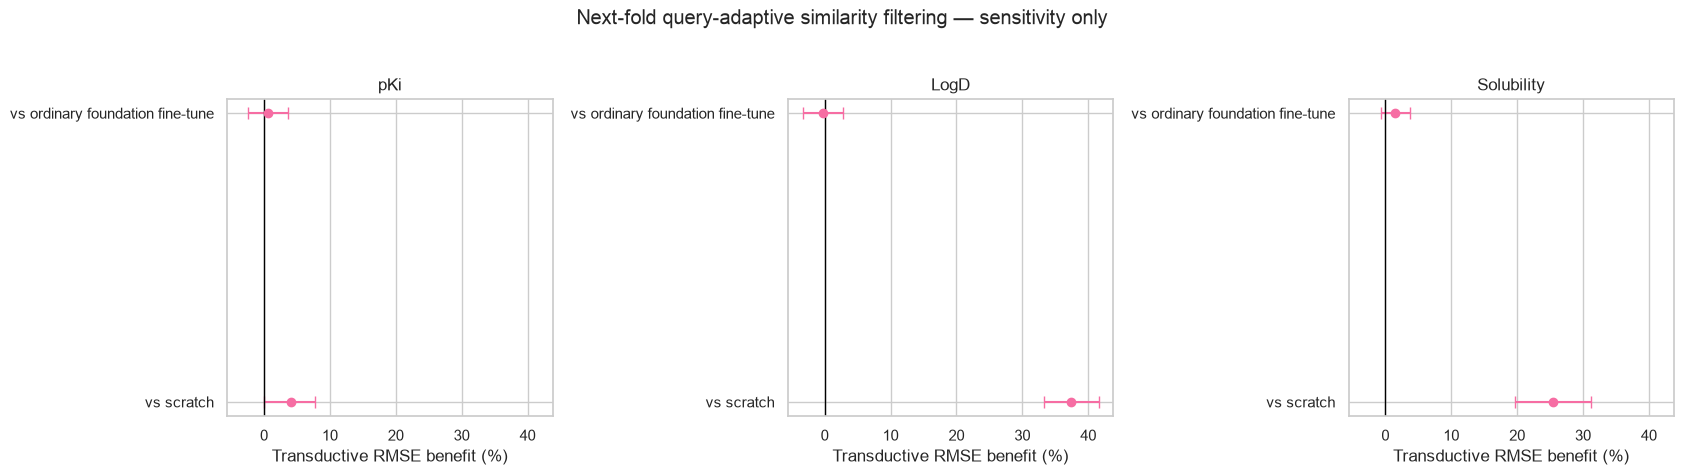

,endpoint,comparison,estimate,ci_low,ci_high
0,LogD,vs scratch,+37.4,+33.3,+41.6
1,LogD,vs ordinary foundation fine-tune,-0.3,-3.3,+2.8
2,Solubility,vs scratch,+25.4,+19.7,+31.2
3,Solubility,vs ordinary foundation fine-tune,+1.4,-0.7,+3.8
4,pKi,vs scratch,+4.1,+0.0,+7.8
5,pKi,vs ordinary foundation fine-tune,+0.6,-2.4,+3.6


In [19]:
transductive_name = "transductive_similarity_filtered"
if transductive_name in set(bootstrap_metrics.strategy):
    trans_boot = (
        bootstrap_metrics.query("evaluation_scope == 'next_fold'")
        .groupby(["target", "strategy", "bootstrap_draw"], as_index=False).rmse.mean()
        .pivot(index=["target", "bootstrap_draw"], columns="strategy", values="rmse")
        .reset_index()
    )
    trans_records = []
    for target, group in trans_boot.groupby("target", sort=False):
        for comparator, label in (("scratch", "vs scratch"),
                                  ("foundation_finetune", "vs ordinary foundation fine-tune")):
            benefit = 100 * (group[comparator] - group[transductive_name]) / group[comparator].abs()
            trans_records.append({
                "target": target,
                "comparison": label,
                "estimate": benefit.mean(),
                "ci_low": benefit.quantile(.025),
                "ci_high": benefit.quantile(.975),
            })
    trans_comparison = pd.DataFrame(trans_records)
    fig, axes = plt.subplots(1, len(TARGETS), figsize=(17, 4.6), sharex=True)
    for ax, target in zip(axes, TARGETS):
        subset = trans_comparison[trans_comparison.target == target].reset_index(drop=True)
        for yi, row in subset.iterrows():
            ax.errorbar(row.estimate, yi,
                        xerr=[[row.estimate-row.ci_low], [row.ci_high-row.estimate]],
                        fmt="o", capsize=4, color=PALETTE[transductive_name])
        ax.axvline(0, color="black", lw=1)
        ax.set_yticks(range(len(subset)), subset.comparison)
        ax.set_title(TARGET_LABEL[target])
        ax.set_xlabel("Transductive RMSE benefit (%)")
    fig.suptitle("Next-fold query-adaptive similarity filtering — sensitivity only", y=1.03)
    fig.tight_layout()
    plt.show()
    display(trans_comparison.assign(endpoint=lambda d: d.target.map(TARGET_LABEL))
            [["endpoint", "comparison", "estimate", "ci_low", "ci_high"]]
            .style.format({"estimate": "{:+.1f}", "ci_low": "{:+.1f}", "ci_high": "{:+.1f}"}))
else:
    display(Markdown("Transductive similarity-filtered results have not yet been added."))


## 10. Foundation encoder adaptation: freeze or fine-tune?

This final view is deliberately restricted to the primary `next_fold` RMSE assessment. The matrix compares every federation strategy with scratch across all four rolling origins. The companion forest directly compares full fine-tuning with freezing the encoder; positive values favour full fine-tuning.


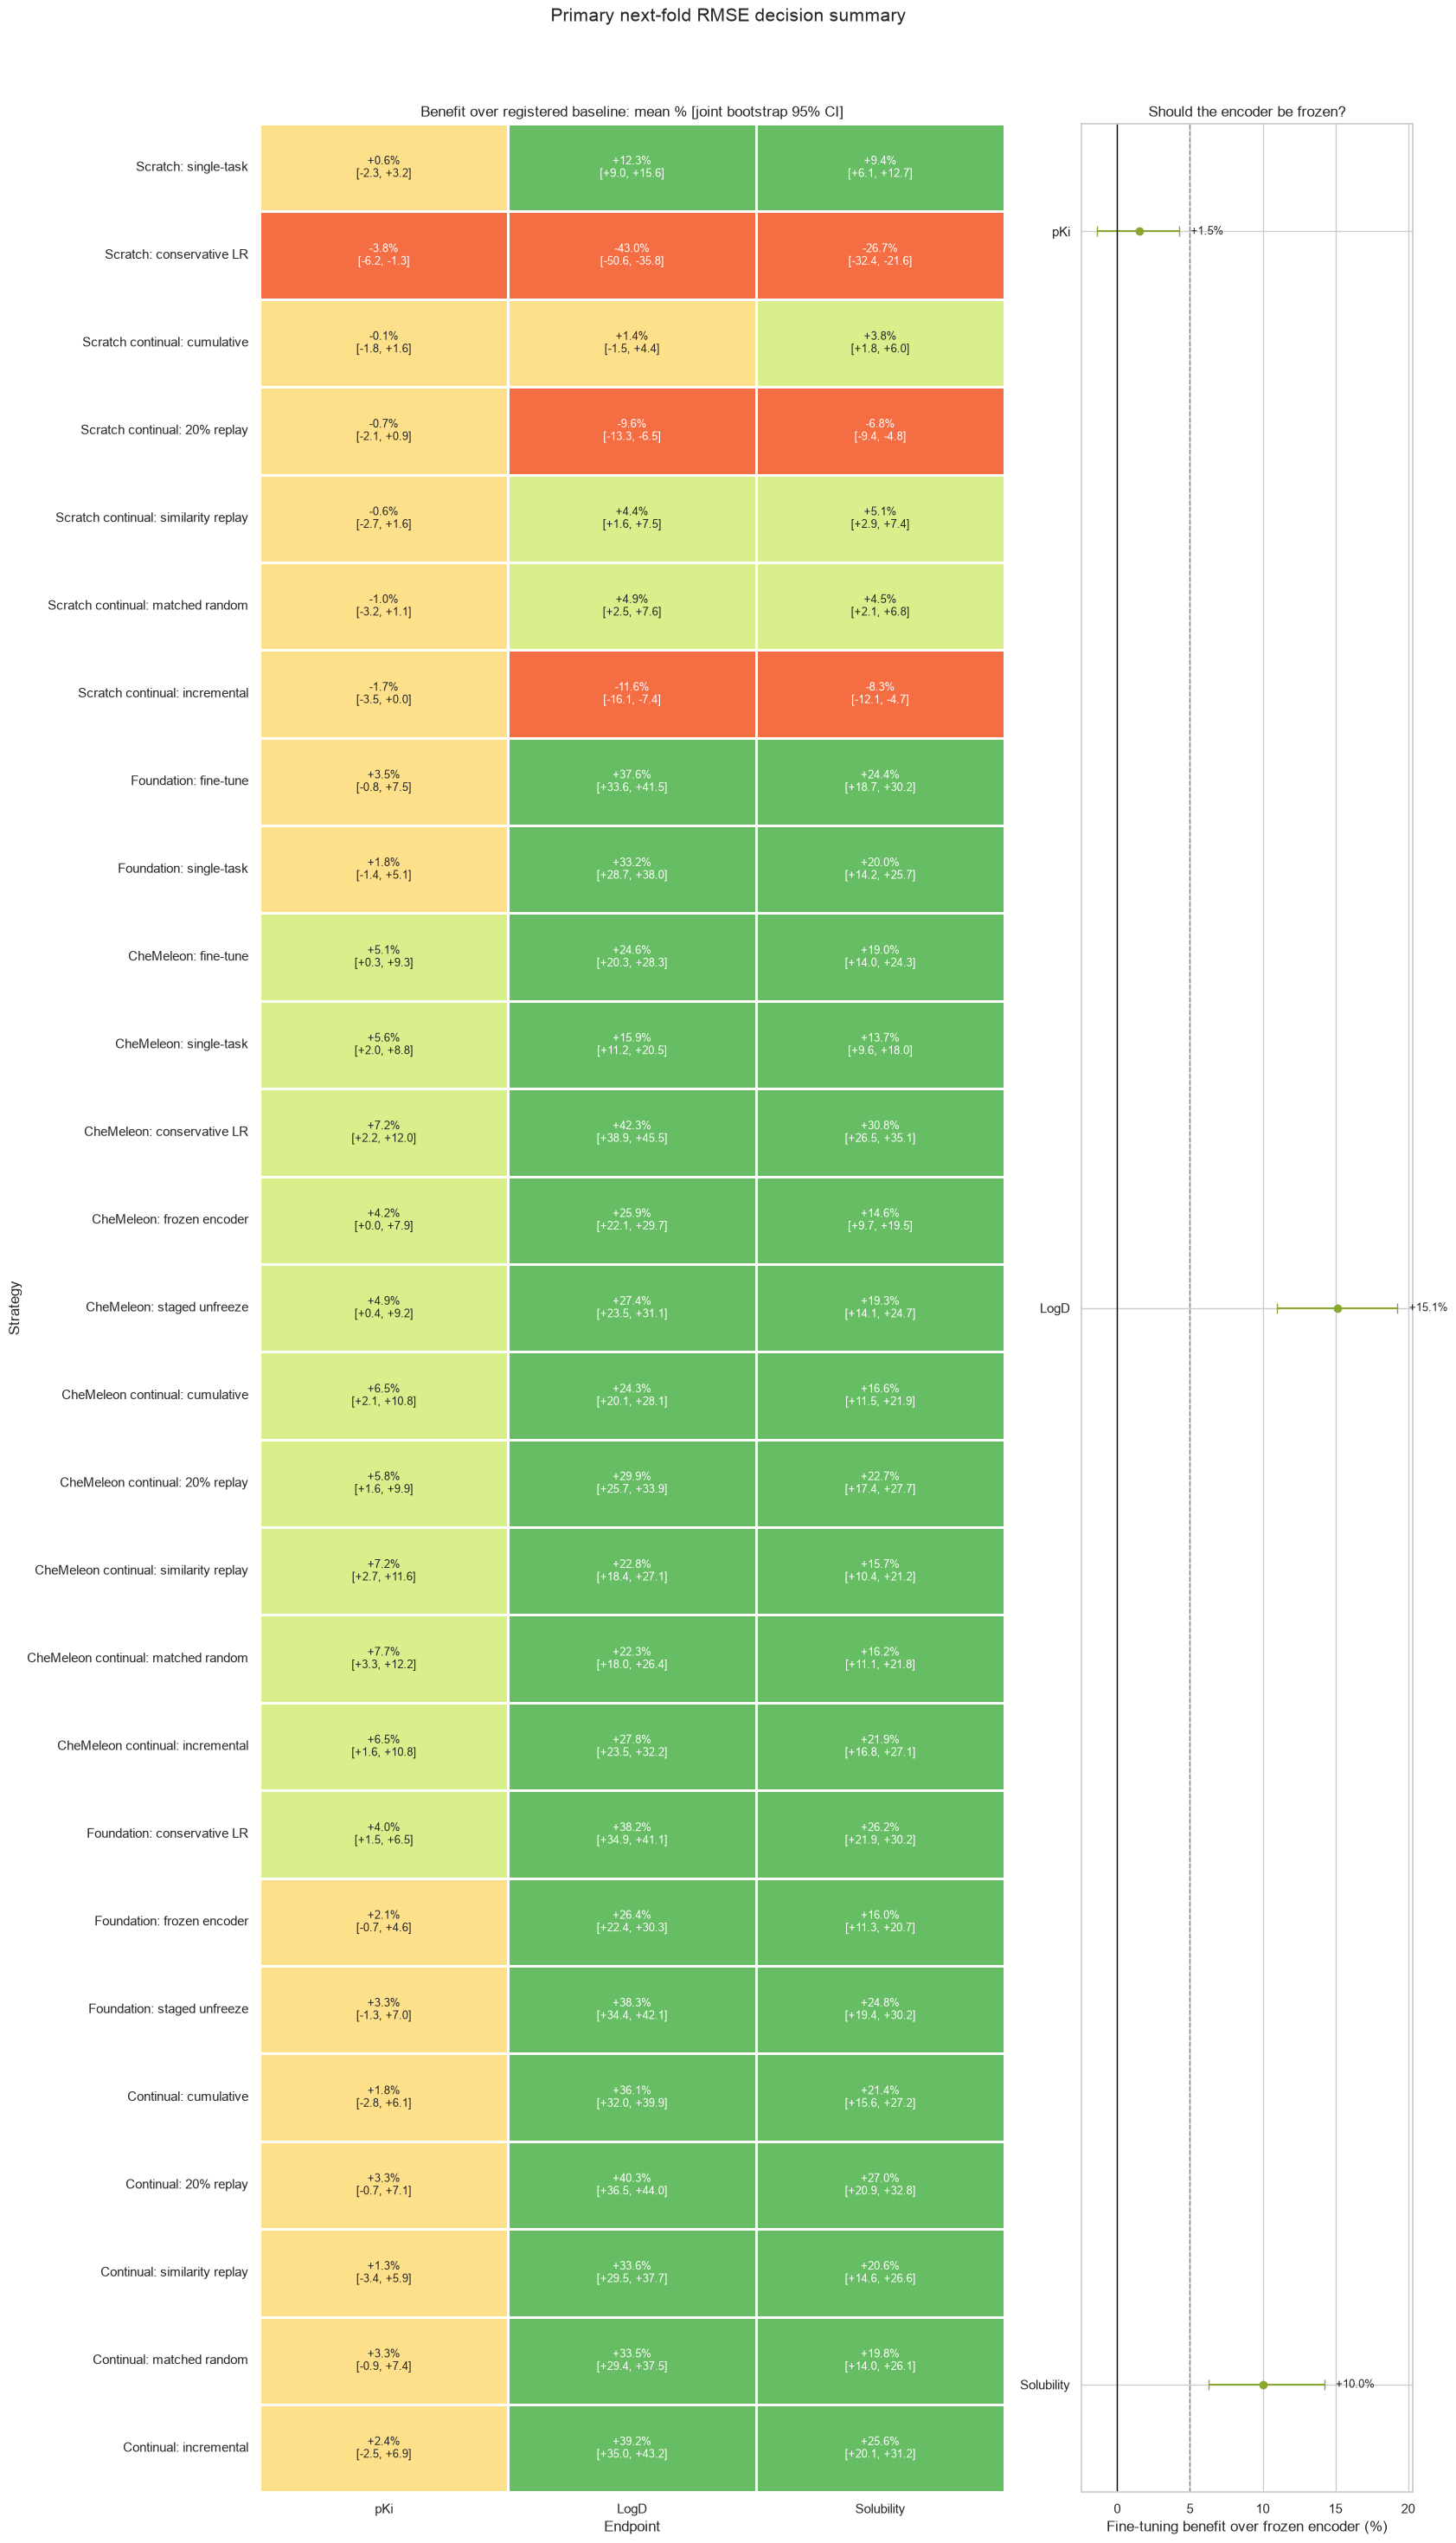


**Decision-oriented interpretation**

- **Best LogD result:** **Foundation: staged unfreeze**, **38.3%** versus its registered baseline (95% CI **34.4–42.1%**).
- **Best solubility result:** **Foundation: staged unfreeze**, **24.8%** versus its registered baseline (95% CI **19.4–30.2%**).
- **pKi:** CheMeleon continual: matched random has the strongest robust estimate: 7.7% [3.3, 12.2%].
- **CheMeleon:** pKi +5.1% [+0.3, +9.3%]; LogD +24.6% [+20.3, +28.3%]; Solubility +19.0% [+14.0, +24.3%]
- **Conservative learning rate:** pKi +4.0% [+1.5, +6.5%]; LogD +38.2% [+34.9, +41.1%]; Solubility +26.2% [+21.9, +30.2%]
- **Historical replay:** pKi +3.3% [-0.7, +7.1%]; LogD +40.3% [+36.5, +44.0%]; Solubility +27.0% [+20.9, +32.8%]
- **Similarity replay:** pKi +1.3% [-3.4, +5.9%]; LogD +33.6% [+29.5, +37.7%]; Solubility +20.6% [+14.6, +26.6%]
- **Size-matched random replay:** pKi +3.3% [-0.9, +7.4%]; LogD +33.5% [+29.4, +37.5%]; Solubility +19.8% [+14.0, +26.1%]
- **Foundation single-task models (baseline: scratch single-task):** pKi +1.8% [-1.4, +5.1%]; LogD +33.2% [+28.7, +38.0%]; Solubility +20.0% [+14.2, +25.7%]
- **Encoder freezing versus full fine-tuning:** pKi: +1.5% [-1.4, +4.3%] (the interval includes no difference); LogD: +15.1% [+11.0, +19.3%] (fine-tuning is practically better); Solubility: +10.0% [+6.3, +14.2%] (fine-tuning is practically better).
- **Operational choice:** use the endpoint-specific evidence rather than imposing one adaptation rule. The experiment-wide synthesis below compares every proposed design choice directly.


In [20]:
from matplotlib.colors import ListedColormap

primary = global_significance.query("evaluation_scope == 'next_fold' and metric == 'rmse'").copy()
primary = primary[~primary.strategy.isin(TRANSDUCTIVE_STRATEGIES)]
foundation_strategies = [
    s for s in STRATEGY_COMPARATOR if s not in TRANSDUCTIVE_STRATEGIES
]

def decision_score(row):
    if row.p_adjusted < .05 and row.relative_ci_low > manifest["practical_threshold_percent"]:
        return 2       # statistically and practically better
    if row.p_adjusted < .05 and row.relative_ci_low > 0:
        return 1       # robust benefit below the practical threshold
    if row.p_adjusted < .05 and row.relative_ci_high < 0:
        return -1      # robustly worse
    return 0           # joint uncertainty includes no difference

primary["decision_score"] = primary.apply(decision_score, axis=1)
score_matrix = primary.pivot(index="strategy", columns="target", values="decision_score").loc[
    foundation_strategies, TARGETS
]
annotation_matrix = primary.assign(
    annotation=lambda d: d.apply(
        lambda row: f"{row.relative_benefit_percent:+.1f}%\n"
                    f"[{row.relative_ci_low:+.1f}, {row.relative_ci_high:+.1f}]",
        axis=1,
    )
).pivot(index="strategy", columns="target", values="annotation").loc[foundation_strategies, TARGETS]

# Direct paired bootstrap: positive means fine-tuning has lower RMSE than freezing.
averaged_bootstrap = (
    bootstrap_metrics.query("evaluation_scope == 'next_fold'")
    .groupby(["target", "strategy", "bootstrap_draw"], as_index=False).rmse.mean()
)
direct_wide = averaged_bootstrap.pivot(
    index=["target", "bootstrap_draw"], columns="strategy", values="rmse"
).reset_index()
direct_records = []
for target, group in direct_wide.groupby("target", sort=False):
    advantage = 100 * (group.foundation_frozen - group.foundation_finetune) / group.foundation_frozen.abs()
    direct_records.append({
        "target": target,
        "estimate": advantage.mean(),
        "ci_low": advantage.quantile(.025),
        "ci_high": advantage.quantile(.975),
    })
direct = pd.DataFrame(direct_records).set_index("target").loc[TARGETS].reset_index()

takeaway_height = max(5.4, 1.0 * len(foundation_strategies) + 1.8)
fig, (ax_matrix, ax_freeze) = plt.subplots(
    1, 2, figsize=(17, takeaway_height), gridspec_kw={"width_ratios": [2.25, 1]}
)
status_cmap = ListedColormap(sns.color_palette("RdYlGn", 4))
sns.heatmap(
    score_matrix,
    annot=annotation_matrix,
    fmt="",
    cmap=status_cmap,
    vmin=-1.5,
    vmax=2.5,
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=ax_matrix,
    annot_kws={"fontsize": 9},
)
ax_matrix.set_xticklabels([TARGET_LABEL[t] for t in TARGETS], rotation=0)
ax_matrix.set_yticklabels([STRATEGY_LABEL[s] for s in foundation_strategies], rotation=0)
ax_matrix.set_xlabel("Endpoint")
ax_matrix.set_ylabel("Strategy")
ax_matrix.set_title("Benefit over registered baseline: mean % [joint bootstrap 95% CI]")

y = np.arange(len(direct))
for yi, row in direct.iterrows():
    ax_freeze.errorbar(
        row.estimate,
        yi,
        xerr=[[row.estimate-row.ci_low], [row.ci_high-row.estimate]],
        fmt="o",
        capsize=4,
        color=PALETTE["foundation_finetune"],
    )
    ax_freeze.text(row.ci_high + .8, yi, f"{row.estimate:+.1f}%", va="center", fontsize=9)
ax_freeze.axvline(0, color="black", lw=1)
ax_freeze.axvline(manifest["practical_threshold_percent"], color="grey", ls="--", lw=1)
ax_freeze.set_yticks(y, [TARGET_LABEL[t] for t in direct.target])
ax_freeze.invert_yaxis()
ax_freeze.set_xlabel("Fine-tuning benefit over frozen encoder (%)")
ax_freeze.set_title("Should the encoder be frozen?")

fig.suptitle("Primary next-fold RMSE decision summary", y=1.02, fontsize=15)
fig.tight_layout()
plt.show()

logd_target = next(t for t in TARGETS if t.startswith("LogD"))
sol_target = next(t for t in TARGETS if "solubility" in t.lower())
pki_target = next(t for t in TARGETS if t.lower() == "pki")
fine = primary.set_index(["target", "strategy"])
freeze_comparison = direct.set_index("target")

def freeze_result_message():
    parts = []
    for target in TARGETS:
        row = freeze_comparison.loc[target]
        if row.ci_low > manifest["practical_threshold_percent"]:
            interpretation = "fine-tuning is practically better"
        elif row.ci_low > 0:
            interpretation = "fine-tuning is better, but below the practical threshold"
        elif row.ci_high < 0:
            interpretation = "freezing is better"
        else:
            interpretation = "the interval includes no difference"
        parts.append(
            f"{TARGET_LABEL[target]}: {row.estimate:+.1f}% "
            f"[{row.ci_low:+.1f}, {row.ci_high:+.1f}%] ({interpretation})"
        )
    return "; ".join(parts) + "."

freeze_message = freeze_result_message()
def strongest_robust_strategy(target):
    candidates = primary[
        (primary.target == target)
        & (primary.baseline_strategy == "scratch")
        & (primary.strategy != "scratch_single_task")
        & (primary.p_adjusted < .05)
        & (primary.relative_ci_low > manifest["practical_threshold_percent"])
    ]
    return None if candidates.empty else candidates.sort_values("relative_benefit_percent").iloc[-1]

best_logd = strongest_robust_strategy(logd_target)
best_sol = strongest_robust_strategy(sol_target)

def best_result_message(endpoint_label, result):
    if result is None:
        return (
            f"No strategy has a multiplicity-adjusted result whose full 95% interval "
            f"clears the {manifest['practical_threshold_percent']:.0f}% practical threshold "
            f"for {endpoint_label}."
        )
    return (
        f"**{STRATEGY_LABEL[result.strategy]}**, **{result.relative_benefit_percent:.1f}%** "
        f"versus its registered baseline (95% CI "
        f"**{result.relative_ci_low:.1f}–{result.relative_ci_high:.1f}%**)."
    )

logd_message = best_result_message("LogD", best_logd)
solubility_message = best_result_message("solubility", best_sol)
pki_robust = primary[
    (primary.target == pki_target) & (primary.p_adjusted < .05) & (primary.relative_ci_low > 0)
]
if pki_robust.empty:
    pki_message = "No strategy has a joint 95% interval entirely above zero; a robust temporal pKi benefit is not established."
else:
    best_pki = pki_robust.sort_values("relative_benefit_percent").iloc[-1]
    pki_message = (
        f"{STRATEGY_LABEL[best_pki.strategy]} has the strongest robust estimate: "
        f"{best_pki.relative_benefit_percent:.1f}% "
        f"[{best_pki.relative_ci_low:.1f}, {best_pki.relative_ci_high:.1f}%]."
    )

chemeleon_rows = primary[primary.strategy == "chemeleon_finetune"].set_index("target")
if chemeleon_rows.empty:
    chemeleon_message = "CheMeleon results have not yet been added to this experiment."
else:
    chemeleon_message = "; ".join(
        f"{TARGET_LABEL[target]} {chemeleon_rows.loc[target, 'relative_benefit_percent']:+.1f}% "
        f"[{chemeleon_rows.loc[target, 'relative_ci_low']:+.1f}, "
        f"{chemeleon_rows.loc[target, 'relative_ci_high']:+.1f}%]"
        for target in TARGETS
    )

def strategy_result_message(strategy):
    rows = primary[primary.strategy == strategy].set_index("target")
    if rows.empty:
        return "Results have not yet been added to this experiment."
    return "; ".join(
        f"{TARGET_LABEL[target]} {rows.loc[target, 'relative_benefit_percent']:+.1f}% "
        f"[{rows.loc[target, 'relative_ci_low']:+.1f}, {rows.loc[target, 'relative_ci_high']:+.1f}%]"
        for target in TARGETS
    )

conservative_message = strategy_result_message("foundation_conservative_lr")
replay_message = strategy_result_message("continual_replay")
similarity_replay_message = strategy_result_message("continual_similarity_replay")
matched_random_message = strategy_result_message("continual_similarity_matched_random")
single_task_message = strategy_result_message("foundation_finetune_single_task")
display(Markdown(
    f'''
**Decision-oriented interpretation**

- **Best LogD result:** {logd_message}
- **Best solubility result:** {solubility_message}
- **pKi:** {pki_message}
- **CheMeleon:** {chemeleon_message}
- **Conservative learning rate:** {conservative_message}
- **Historical replay:** {replay_message}
- **Similarity replay:** {similarity_replay_message}
- **Size-matched random replay:** {matched_random_message}
- **Foundation single-task models (baseline: scratch single-task):** {single_task_message}
- **Encoder freezing versus full fine-tuning:** {freeze_message}
- **Operational choice:** use the endpoint-specific evidence rather than imposing one adaptation rule. The experiment-wide synthesis below compares every proposed design choice directly.
'''
))


## 11. Experiment-wide key findings

This is the final decision view. It uses only the primary `next_fold` challenge and averages the four rolling origins equally. The first panel ranks all **prospective** methods by RMSE. The second panel isolates the design decisions we explicitly tested. Positive values mean the candidate named on the row has lower RMSE than its comparator; intervals are paired-bootstrap 95% intervals, and adjusted p-values come from the appropriate all-origin comparison family.

The query-adaptive method is reported separately because it uses the structures of the upcoming prediction batch. It is not allowed to determine the primary prospective winner.


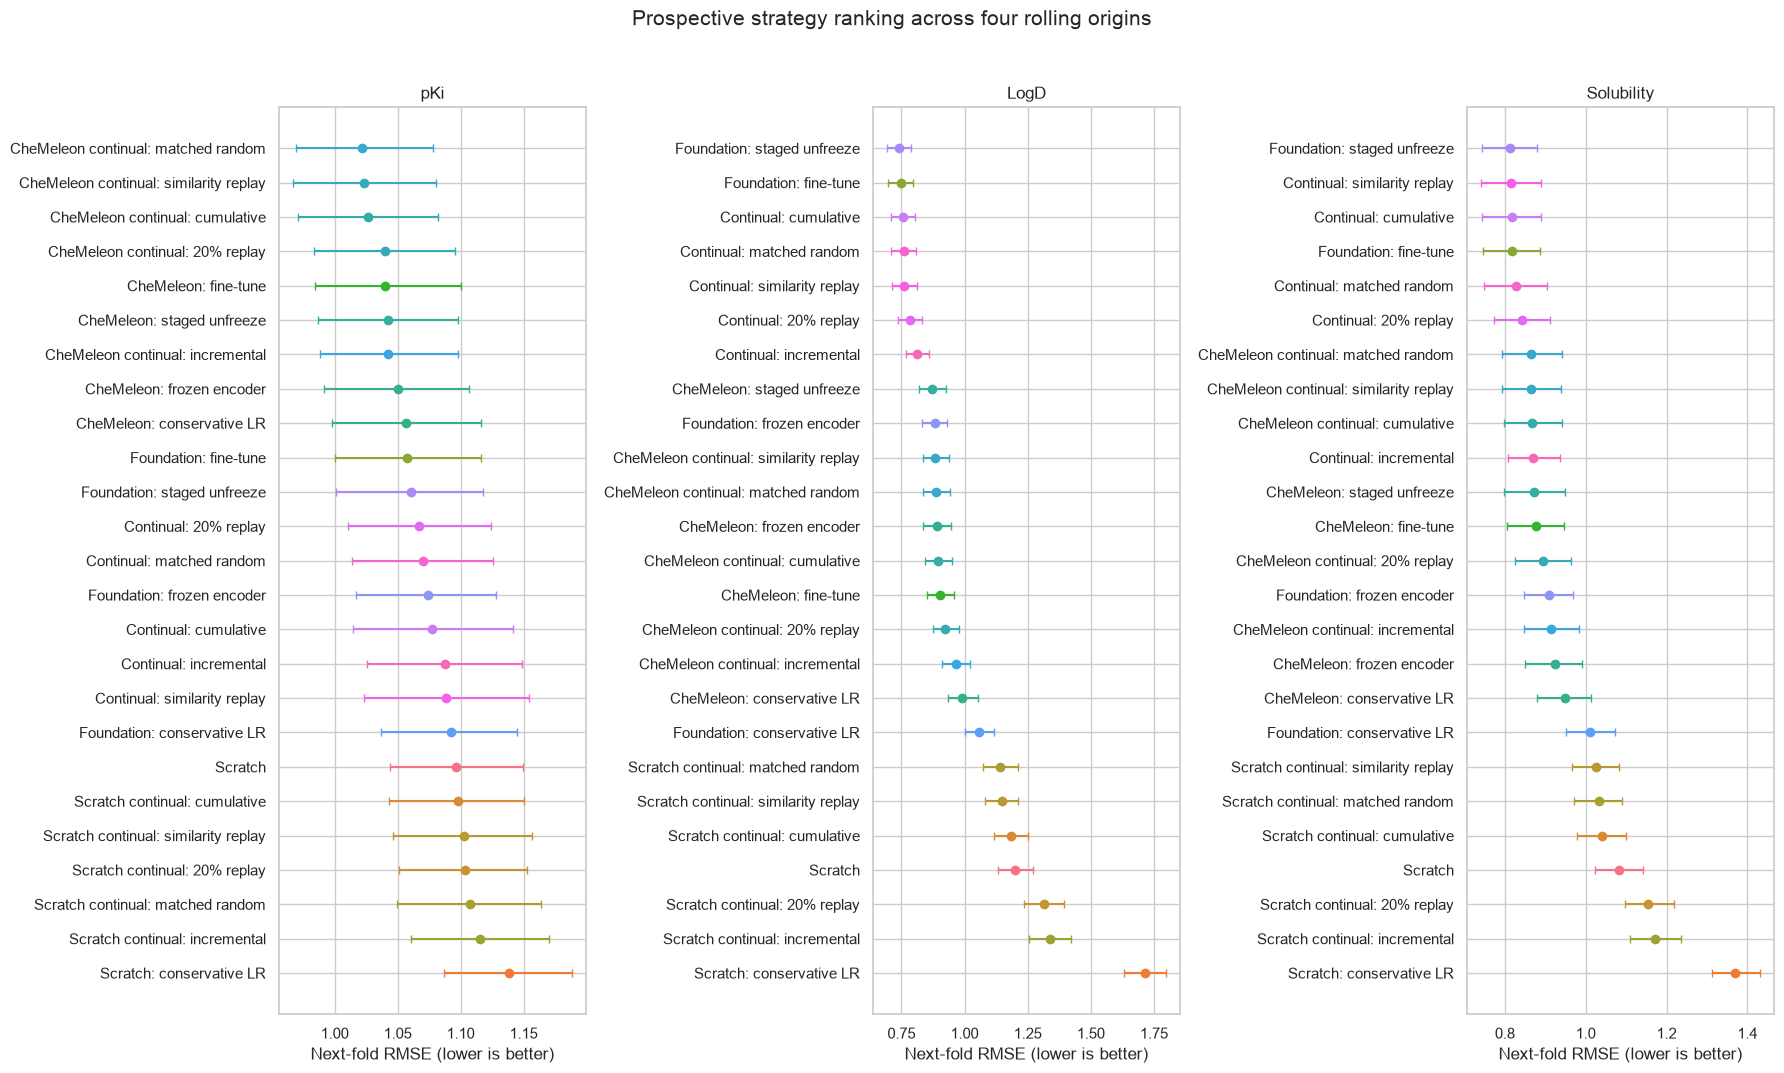

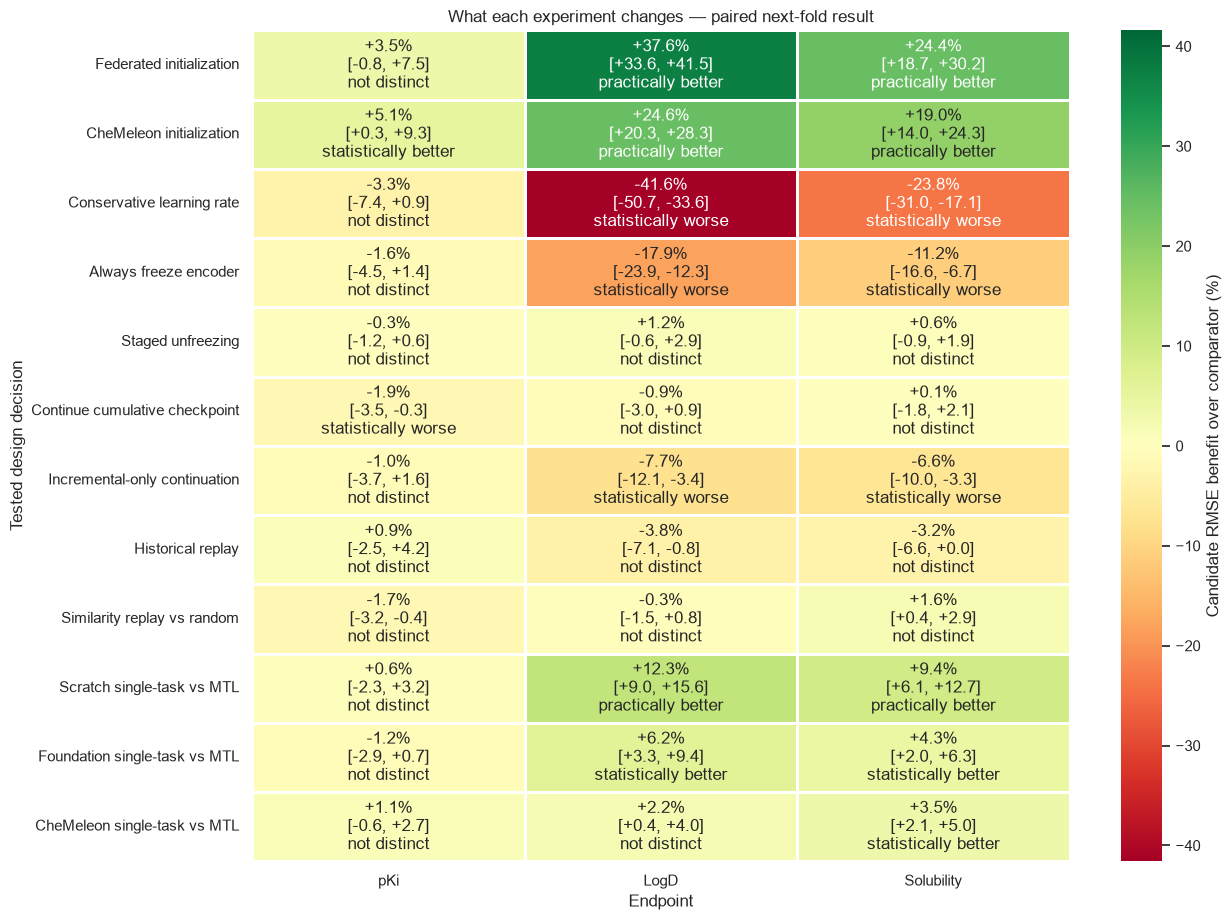

,question,endpoint,candidate_label,comparator_label,estimate,ci_low,ci_high,p_adjusted,finding,comparison_family
0,Federated initialization,LogD,Foundation: fine-tune,Scratch,+37.6,+33.6,+41.5,0,practically better,prospective_multitask
1,Federated initialization,Solubility,Foundation: fine-tune,Scratch,+24.4,+18.7,+30.2,0,practically better,prospective_multitask
2,Federated initialization,pKi,Foundation: fine-tune,Scratch,+3.5,-0.8,+7.5,5.89e-10,not distinct,prospective_multitask
3,CheMeleon initialization,LogD,CheMeleon: fine-tune,Scratch,+24.6,+20.3,+28.3,0,practically better,prospective_multitask
4,CheMeleon initialization,Solubility,CheMeleon: fine-tune,Scratch,+19.0,+14.0,+24.3,0,practically better,prospective_multitask
5,CheMeleon initialization,pKi,CheMeleon: fine-tune,Scratch,+5.1,+0.3,+9.3,0,statistically better,prospective_multitask
6,Conservative learning rate,LogD,Foundation: conservative LR,Foundation: fine-tune,-41.6,-50.7,-33.6,0,statistically worse,prospective_multitask
7,Conservative learning rate,Solubility,Foundation: conservative LR,Foundation: fine-tune,-23.8,-31.0,-17.1,0,statistically worse,prospective_multitask
8,Conservative learning rate,pKi,Foundation: conservative LR,Foundation: fine-tune,-3.3,-7.4,+0.9,5.56e-08,not distinct,prospective_multitask
9,Always freeze encoder,LogD,Foundation: frozen encoder,Foundation: fine-tune,-17.9,-23.9,-12.3,0,statistically worse,prospective_multitask


In [21]:
primary_boot = (
    bootstrap_metrics.query("evaluation_scope == 'next_fold'")
    .groupby(["target", "strategy", "bootstrap_draw"], as_index=False).rmse.mean()
)
prospective_strategies = [
    strategy
    for strategy in manifest["strategy_families"]["prospective_multitask"]
    if strategy in set(primary_boot.strategy)
]

ranking = (
    primary_boot[primary_boot.strategy.isin(prospective_strategies)]
    .groupby(["target", "strategy"], as_index=False)
    .rmse.agg(estimate="mean", ci_low=lambda x: x.quantile(.025), ci_high=lambda x: x.quantile(.975))
)
ranking["rank"] = ranking.groupby("target").estimate.rank(method="min").astype(int)
ranking["endpoint"] = ranking.target.map(TARGET_LABEL)
ranking["method"] = ranking.strategy.map(STRATEGY_LABEL)

fig, axes = plt.subplots(1, len(TARGETS), figsize=(18, max(5.5, .42 * len(prospective_strategies))))
for ax, target in zip(axes, TARGETS):
    subset = ranking[ranking.target == target].sort_values("estimate").reset_index(drop=True)
    y = np.arange(len(subset))
    for yi, row in subset.iterrows():
        ax.errorbar(
            row.estimate, yi,
            xerr=[[row.estimate-row.ci_low], [row.ci_high-row.estimate]],
            fmt="o", capsize=3, color=PALETTE[row.strategy],
        )
    ax.set_yticks(y, subset.method)
    ax.invert_yaxis()
    ax.set_xlabel("Next-fold RMSE (lower is better)")
    ax.set_title(TARGET_LABEL[target])
fig.suptitle("Prospective strategy ranking across four rolling origins", y=1.02, fontsize=15)
fig.tight_layout()
plt.show()

comparison_specs = [
    ("Federated initialization", "foundation_finetune", "scratch", "prospective_multitask"),
    ("CheMeleon initialization", "chemeleon_finetune", "scratch", "prospective_multitask"),
    ("Conservative learning rate", "foundation_conservative_lr", "foundation_finetune", "prospective_multitask"),
    ("Always freeze encoder", "foundation_frozen", "foundation_finetune", "prospective_multitask"),
    ("Staged unfreezing", "foundation_staged_unfreeze", "foundation_finetune", "prospective_multitask"),
    ("Continue cumulative checkpoint", "continual_cumulative", "foundation_finetune", "prospective_multitask"),
    ("Incremental-only continuation", "continual_incremental", "continual_cumulative", "prospective_multitask"),
    ("Historical replay", "continual_replay", "continual_cumulative", "prospective_multitask"),
    ("Similarity replay vs random", "continual_similarity_replay", "continual_similarity_matched_random", "prospective_multitask"),
    ("Scratch single-task vs MTL", "scratch_single_task", "scratch", "task_formulation"),
    ("Foundation single-task vs MTL", "foundation_finetune_single_task", "foundation_finetune", "task_formulation"),
    ("CheMeleon single-task vs MTL", "chemeleon_finetune_single_task", "chemeleon_finetune", "task_formulation"),
    ("Transductive similarity", "transductive_similarity_filtered", "foundation_finetune", "transductive_multitask"),
]

wide_boot = primary_boot.pivot(
    index=["target", "bootstrap_draw"], columns="strategy", values="rmse"
).reset_index()
all_origin_tests = pairwise_tests[
    pairwise_tests["origin"].astype(str).eq("all")
    & pairwise_tests.evaluation_scope.eq("next_fold")
    & pairwise_tests.metric.eq("rmse")
].copy()

def adjusted_pairwise_p(target, candidate, comparator, family):
    rows = all_origin_tests[
        (all_origin_tests.target == target)
        & (all_origin_tests.comparison_family == family)
        & (
            ((all_origin_tests.method_a == candidate) & (all_origin_tests.method_b == comparator))
            | ((all_origin_tests.method_a == comparator) & (all_origin_tests.method_b == candidate))
        )
    ]
    return np.nan if rows.empty else float(rows.iloc[0].p_adjusted)

comparison_records = []
for question, candidate, comparator, family in comparison_specs:
    if candidate not in wide_boot or comparator not in wide_boot:
        continue
    for target, group in wide_boot.groupby("target", sort=False):
        benefit = 100 * (group[comparator] - group[candidate]) / group[comparator].abs()
        estimate = benefit.mean()
        ci_low, ci_high = benefit.quantile([.025, .975])
        p_adjusted = adjusted_pairwise_p(target, candidate, comparator, family)
        if p_adjusted < .05 and ci_low > manifest["practical_threshold_percent"]:
            finding = "practically better"
        elif p_adjusted < .05 and ci_low > 0:
            finding = "statistically better"
        elif p_adjusted < .05 and ci_high < 0:
            finding = "statistically worse"
        else:
            finding = "not distinct"
        comparison_records.append({
            "question": question,
            "candidate": candidate,
            "comparator": comparator,
            "comparison_family": family,
            "target": target,
            "estimate": estimate,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_adjusted": p_adjusted,
            "finding": finding,
        })
key_comparisons = pd.DataFrame(comparison_records)

prospective_questions = [q for q, _, _, family in comparison_specs if family != "transductive_multitask"]
plot_comparisons = key_comparisons[key_comparisons.question.isin(prospective_questions)].copy()
effect_matrix = plot_comparisons.pivot(index="question", columns="target", values="estimate").loc[
    prospective_questions, TARGETS
]
effect_annotations = plot_comparisons.assign(
    annotation=lambda d: d.apply(
        lambda row: f"{row.estimate:+.1f}%\n[{row.ci_low:+.1f}, {row.ci_high:+.1f}]\n{row.finding}",
        axis=1,
    )
).pivot(index="question", columns="target", values="annotation").loc[prospective_questions, TARGETS]

limit = max(5, np.nanmax(np.abs(effect_matrix.to_numpy())))
fig, ax = plt.subplots(figsize=(13, max(7, .78 * len(effect_matrix))))
sns.heatmap(
    effect_matrix,
    annot=effect_annotations,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Candidate RMSE benefit over comparator (%)"},
    ax=ax,
)
ax.set_xticklabels([TARGET_LABEL[target] for target in TARGETS], rotation=0)
ax.set_xlabel("Endpoint")
ax.set_ylabel("Tested design decision")
ax.set_title("What each experiment changes — paired next-fold result")
fig.tight_layout()
plt.show()

display(
    key_comparisons.assign(
        endpoint=lambda d: d.target.map(TARGET_LABEL),
        candidate_label=lambda d: d.candidate.map(STRATEGY_LABEL),
        comparator_label=lambda d: d.comparator.map(STRATEGY_LABEL),
    )[["question", "endpoint", "candidate_label", "comparator_label", "estimate",
       "ci_low", "ci_high", "p_adjusted", "finding", "comparison_family"]]
    .style.format({
        "estimate": "{:+.1f}", "ci_low": "{:+.1f}", "ci_high": "{:+.1f}",
        "p_adjusted": "{:.3g}",
    })
)


In [22]:
def comparison_summary(question):
    subset = key_comparisons[key_comparisons.question == question].set_index("target")
    if subset.empty:
        return "result unavailable"
    return "; ".join(
        f"{TARGET_LABEL[target]} {subset.loc[target, 'estimate']:+.1f}% "
        f"[{subset.loc[target, 'ci_low']:+.1f}, {subset.loc[target, 'ci_high']:+.1f}%], "
        f"{subset.loc[target, 'finding']}"
        for target in TARGETS
    )

winner_lines = []
for target in TARGETS:
    winner = ranking[(ranking.target == target) & (ranking["rank"] == 1)].iloc[0]
    versus_scratch = primary[
        (primary.target == target)
        & (primary.strategy == winner.strategy)
        & (primary.baseline_strategy == "scratch")
    ]
    if versus_scratch.empty:
        evidence = "no registered scratch comparison"
    else:
        result = versus_scratch.iloc[0]
        evidence = (
            f"{result.relative_benefit_percent:+.1f}% versus scratch "
            f"[{result.relative_ci_low:+.1f}, {result.relative_ci_high:+.1f}%], "
            f"adjusted p={result.p_adjusted:.3g}; {result.conclusion}"
        )
    winner_lines.append(
        f"- **{TARGET_LABEL[target]} prospective winner:** **{STRATEGY_LABEL[winner.strategy]}** "
        f"(RMSE {winner.estimate:.3f} [{winner.ci_low:.3f}, {winner.ci_high:.3f}]); {evidence}."
    )

transductive_summary = comparison_summary("Transductive similarity")
display(Markdown(
    "\n".join([
        "### Bottom line",
        "",
        *winner_lines,
        "",
        f"- **Does federation help?** {comparison_summary('Federated initialization')}.",
        f"- **CheMeleon:** {comparison_summary('CheMeleon initialization')}.",
        f"- **Freeze strategy:** always frozen — {comparison_summary('Always freeze encoder')}; "
        f"staged unfreezing — {comparison_summary('Staged unfreezing')}.",
        f"- **Learning-rate sensitivity:** {comparison_summary('Conservative learning rate')}.",
        f"- **Continual learning:** cumulative checkpoint — {comparison_summary('Continue cumulative checkpoint')}; "
        f"incremental-only — {comparison_summary('Incremental-only continuation')}; "
        f"historical replay — {comparison_summary('Historical replay')}.",
        f"- **Similarity selection:** similarity replay versus its size-matched random control — "
        f"{comparison_summary('Similarity replay vs random')}.",
        f"- **Separate endpoint models:** scratch single-task versus scratch MTL — "
        f"{comparison_summary('Scratch single-task vs MTL')}; foundation single-task versus "
        f"foundation MTL — {comparison_summary('Foundation single-task vs MTL')}; CheMeleon "
        f"single-task versus CheMeleon MTL — {comparison_summary('CheMeleon single-task vs MTL')}.",
        f"- **Transductive sensitivity (not a prospective claim):** {transductive_summary}.",
        "",
        "A method is labelled *practically better* only when the multiplicity-adjusted test is "
        "significant and the complete paired-bootstrap interval exceeds the configured 5% RMSE "
        "benefit threshold. Otherwise the wording deliberately remains more cautious.",
    ])
))


### Bottom line

- **pKi prospective winner:** **CheMeleon continual: matched random** (RMSE 1.022 [0.969, 1.078]); no registered scratch comparison.
- **LogD prospective winner:** **Foundation: staged unfreeze** (RMSE 0.740 [0.693, 0.787]); +38.3% versus scratch [+34.4, +42.1%], adjusted p=6.5e-237; statistically and practically better.
- **Solubility prospective winner:** **Foundation: staged unfreeze** (RMSE 0.813 [0.744, 0.880]); +24.8% versus scratch [+19.4, +30.2%], adjusted p=7.57e-174; statistically and practically better.

- **Does federation help?** pKi +3.5% [-0.8, +7.5%], not distinct; LogD +37.6% [+33.6, +41.5%], practically better; Solubility +24.4% [+18.7, +30.2%], practically better.
- **CheMeleon:** pKi +5.1% [+0.3, +9.3%], statistically better; LogD +24.6% [+20.3, +28.3%], practically better; Solubility +19.0% [+14.0, +24.3%], practically better.
- **Freeze strategy:** always frozen — pKi -1.6% [-4.5, +1.4%], not distinct; LogD -17.9% [-23.9, -12.3%], statistically worse; Solubility -11.2% [-16.6, -6.7%], statistically worse; staged unfreezing — pKi -0.3% [-1.2, +0.6%], not distinct; LogD +1.2% [-0.6, +2.9%], not distinct; Solubility +0.6% [-0.9, +1.9%], not distinct.
- **Learning-rate sensitivity:** pKi -3.3% [-7.4, +0.9%], not distinct; LogD -41.6% [-50.7, -33.6%], statistically worse; Solubility -23.8% [-31.0, -17.1%], statistically worse.
- **Continual learning:** cumulative checkpoint — pKi -1.9% [-3.5, -0.3%], statistically worse; LogD -0.9% [-3.0, +0.9%], not distinct; Solubility +0.1% [-1.8, +2.1%], not distinct; incremental-only — pKi -1.0% [-3.7, +1.6%], not distinct; LogD -7.7% [-12.1, -3.4%], statistically worse; Solubility -6.6% [-10.0, -3.3%], statistically worse; historical replay — pKi +0.9% [-2.5, +4.2%], not distinct; LogD -3.8% [-7.1, -0.8%], not distinct; Solubility -3.2% [-6.6, +0.0%], not distinct.
- **Similarity selection:** similarity replay versus its size-matched random control — pKi -1.7% [-3.2, -0.4%], not distinct; LogD -0.3% [-1.5, +0.8%], not distinct; Solubility +1.6% [+0.4, +2.9%], not distinct.
- **Separate endpoint models:** scratch single-task versus scratch MTL — pKi +0.6% [-2.3, +3.2%], not distinct; LogD +12.3% [+9.0, +15.6%], practically better; Solubility +9.4% [+6.1, +12.7%], practically better; foundation single-task versus foundation MTL — pKi -1.2% [-2.9, +0.7%], not distinct; LogD +6.2% [+3.3, +9.4%], statistically better; Solubility +4.3% [+2.0, +6.3%], statistically better; CheMeleon single-task versus CheMeleon MTL — pKi +1.1% [-0.6, +2.7%], not distinct; LogD +2.2% [+0.4, +4.0%], not distinct; Solubility +3.5% [+2.1, +5.0%], statistically better.
- **Transductive sensitivity (not a prospective claim):** pKi +0.6% [-2.4, +3.6%], not distinct; LogD -0.3% [-3.3, +2.8%], not distinct; Solubility +1.4% [-0.7, +3.8%], not distinct.

A method is labelled *practically better* only when the multiplicity-adjusted test is significant and the complete paired-bootstrap interval exceeds the configured 5% RMSE benefit threshold. Otherwise the wording deliberately remains more cautious.

## 12. North star: best federation versus the strongest alternative

This is the confirmatory-style final takeaway.

- **Alternatives:** every applicable scratch and CheMeleon counterpart: MTL/STL, conservative learning rate, checkpoint continuation, and replay variants, plus frozen and staged-unfreezing CheMeleon encoders.
- **Federation candidates:** the exact corresponding prospective grid initialized from the supplied federated model: MTL/STL, conservative learning rate, freezing, staged unfreezing, checkpoint continuation, and replay variants.
- **No test-batch selection:** for each held-out rolling origin, the best candidate in each group is chosen using only the other three origins. Performance is then measured on the untouched origin. This leave-one-origin-out selection is repeated for all four challenges.
- **Matched inference:** the four held-out results are averaged within each of the 25 matched seed replicates. The three endpoint p-values are Holm-adjusted. Joint paired-bootstrap intervals supply the uncertainty and the 5% practical threshold.

This estimates the performance of the *selection procedure*, rather than selecting a winner and evaluating it on the same origins. A second, explicitly exploratory dominance audit asks whether the best observed federated model beats every tested alternative after family-wide adjustment.


candidate_group,n_strategies,strategies,coverage
Alternative,18,"Scratch, Scratch: single-task, Scratch: conservative LR, Scratch continual: cumulative, Scratch continual: 20% replay, Scratch continual: similarity replay, Scratch continual: matched random, Scratch continual: incremental, CheMeleon: fine-tune, CheMeleon: single-task, CheMeleon: conservative LR, CheMeleon: frozen encoder, CheMeleon: staged unfreeze, CheMeleon continual: cumulative, CheMeleon continual: 20% replay, CheMeleon continual: similarity replay, CheMeleon continual: matched random, CheMeleon continual: incremental","scratch and CheMeleon: MTL/STL, LR and continual/replay variants; CheMeleon also frozen/staged"
Federation,10,"Foundation: fine-tune, Foundation: single-task, Foundation: conservative LR, Foundation: frozen encoder, Foundation: staged unfreeze, Continual: cumulative, Continual: 20% replay, Continual: similarity replay, Continual: matched random, Continual: incremental","MTL/STL, LR, frozen/staged, cumulative/incremental, replay and similarity variants"


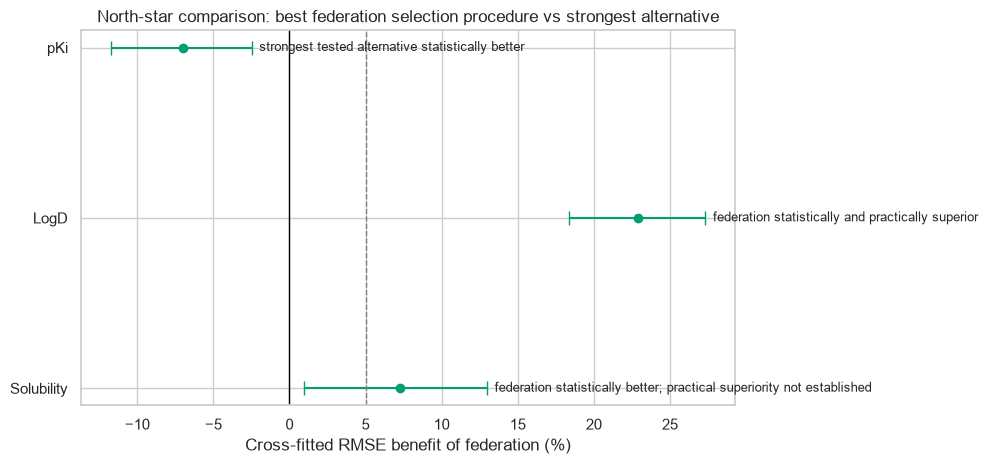

endpoint,held_out_origin,selection_origins,selected_federation,selected_alternative
pKi,1,"2, 3, 4",Foundation: fine-tune,CheMeleon continual: matched random
pKi,2,"1, 3, 4",Foundation: staged unfreeze,CheMeleon continual: matched random
pKi,3,"1, 2, 4",Foundation: fine-tune,CheMeleon: single-task
pKi,4,"1, 2, 3",Continual: incremental,CheMeleon continual: matched random
LogD,1,"2, 3, 4",Foundation: single-task,CheMeleon continual: similarity replay
LogD,2,"1, 3, 4",Foundation: single-task,CheMeleon: staged unfreeze
LogD,3,"1, 2, 4",Foundation: single-task,CheMeleon: staged unfreeze
LogD,4,"1, 2, 3",Foundation: single-task,CheMeleon: frozen encoder
Solubility,1,"2, 3, 4",Foundation: single-task,CheMeleon: single-task
Solubility,2,"1, 3, 4",Foundation: single-task,CheMeleon: single-task


endpoint,estimate,ci_low,ci_high,test,p_adjusted,effect_size_dz,n_matched_replicates,conclusion
pKi,-7.0,-11.7,-2.5,paired t-test,4.06e-10,-2.02,25,strongest tested alternative statistically better
LogD,+22.9,+18.3,+27.3,paired t-test,1.12e-23,+8.54,25,federation statistically and practically superior
Solubility,+7.3,+0.9,+13.0,paired t-test,2.93e-12,+2.66,25,federation statistically better; practical superiority not established


In [23]:
ALTERNATIVE_CANDIDATES = [
    strategy for strategy in STRATEGIES
    if strategy.startswith("scratch") or strategy.startswith("chemeleon")
]
FEDERATED_CANDIDATES = [
    strategy for strategy in STRATEGIES
    if strategy not in set(ALTERNATIVE_CANDIDATES) | TRANSDUCTIVE_STRATEGIES
]

fairness_audit = pd.DataFrame([
    {
        "candidate_group": "Alternative",
        "n_strategies": len(ALTERNATIVE_CANDIDATES),
        "strategies": ", ".join(STRATEGY_LABEL[s] for s in ALTERNATIVE_CANDIDATES),
        "coverage": "scratch and CheMeleon: MTL/STL, LR and continual/replay variants; CheMeleon also frozen/staged",
    },
    {
        "candidate_group": "Federation",
        "n_strategies": len(FEDERATED_CANDIDATES),
        "strategies": ", ".join(STRATEGY_LABEL[s] for s in FEDERATED_CANDIDATES),
        "coverage": "MTL/STL, LR, frozen/staged, cumulative/incremental, replay and similarity variants",
    },
])
display(fairness_audit.style.hide(axis="index"))

observed_next = full_metrics.query("evaluation_scope == 'next_fold'").copy()
selection_records = []
for target in TARGETS:
    target_data = observed_next[observed_next.target == target]
    for held_out_origin in sorted(target_data.origin.unique()):
        selection_data = target_data[target_data.origin != held_out_origin]
        scores = selection_data.groupby("strategy").rmse.mean()
        best_federation = scores.loc[FEDERATED_CANDIDATES].idxmin()
        best_alternative = scores.loc[ALTERNATIVE_CANDIDATES].idxmin()
        selection_records.append({
            "target": target,
            "held_out_origin": held_out_origin,
            "selected_federation": best_federation,
            "selected_alternative": best_alternative,
            "selection_origins": ", ".join(
                str(origin) for origin in sorted(target_data.origin.unique())
                if origin != held_out_origin
            ),
        })
crossfit_selections = pd.DataFrame(selection_records)

pair_records = []
for row in crossfit_selections.itertuples(index=False):
    held_out = observed_next[
        (observed_next.target == row.target)
        & (observed_next.origin == row.held_out_origin)
    ]
    federation = held_out[held_out.strategy == row.selected_federation][
        ["replicate_id", "rmse"]
    ].rename(columns={"rmse": "federation_rmse"})
    alternative = held_out[held_out.strategy == row.selected_alternative][
        ["replicate_id", "rmse"]
    ].rename(columns={"rmse": "alternative_rmse"})
    paired = federation.merge(alternative, on="replicate_id", validate="one_to_one")
    paired["target"] = row.target
    paired["held_out_origin"] = row.held_out_origin
    paired["selected_federation"] = row.selected_federation
    paired["selected_alternative"] = row.selected_alternative
    pair_records.append(paired)
crossfit_pairs = pd.concat(pair_records, ignore_index=True)

origin_bootstrap = bootstrap_metrics.query("evaluation_scope == 'next_fold'")[
    ["origin", "target", "strategy", "bootstrap_draw", "rmse"]
]
bootstrap_records = []
for row in crossfit_selections.itertuples(index=False):
    held_out = origin_bootstrap[
        (origin_bootstrap.target == row.target)
        & (origin_bootstrap.origin == row.held_out_origin)
    ]
    federation = held_out[held_out.strategy == row.selected_federation][
        ["bootstrap_draw", "rmse"]
    ].rename(columns={"rmse": "federation_rmse"})
    alternative = held_out[held_out.strategy == row.selected_alternative][
        ["bootstrap_draw", "rmse"]
    ].rename(columns={"rmse": "alternative_rmse"})
    paired = federation.merge(alternative, on="bootstrap_draw", validate="one_to_one")
    paired["target"] = row.target
    paired["held_out_origin"] = row.held_out_origin
    bootstrap_records.append(paired)
crossfit_bootstrap = pd.concat(bootstrap_records, ignore_index=True)

crossfit_bootstrap = (
    crossfit_bootstrap
    .groupby(["target", "bootstrap_draw"], as_index=False)
    .agg(federation_rmse=("federation_rmse", "mean"),
         alternative_rmse=("alternative_rmse", "mean"))
)
crossfit_bootstrap["benefit_percent"] = 100 * (
    crossfit_bootstrap.alternative_rmse - crossfit_bootstrap.federation_rmse
) / crossfit_bootstrap.alternative_rmse.abs()

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted_sorted = np.maximum.accumulate(
        (len(p_values) - np.arange(len(p_values))) * p_values[order]
    )
    adjusted = np.empty_like(adjusted_sorted)
    adjusted[order] = np.minimum(adjusted_sorted, 1.0)
    return adjusted

north_star_records = []
for target in TARGETS:
    replicate_pairs = (
        crossfit_pairs[crossfit_pairs.target == target]
        .groupby("replicate_id", as_index=False)
        .agg(federation_rmse=("federation_rmse", "mean"),
             alternative_rmse=("alternative_rmse", "mean"))
    )
    differences = replicate_pairs.alternative_rmse - replicate_pairs.federation_rmse
    shapiro_p = stats.shapiro(differences).pvalue
    if shapiro_p >= .001:
        test_name = "paired t-test"
        p_value = stats.ttest_rel(
            replicate_pairs.alternative_rmse,
            replicate_pairs.federation_rmse,
        ).pvalue
    elif np.allclose(differences, 0):
        test_name = "Wilcoxon signed-rank"
        p_value = 1.0
    else:
        test_name = "Wilcoxon signed-rank"
        p_value = stats.wilcoxon(differences).pvalue
    boot = crossfit_bootstrap[crossfit_bootstrap.target == target].benefit_percent
    north_star_records.append({
        "target": target,
        "estimate": boot.mean(),
        "ci_low": boot.quantile(.025),
        "ci_high": boot.quantile(.975),
        "raw_p": p_value,
        "test": test_name,
        "shapiro_p": shapiro_p,
        "effect_size_dz": differences.mean() / differences.std(ddof=1),
        "n_matched_replicates": len(replicate_pairs),
    })
north_star = pd.DataFrame(north_star_records)
north_star["p_adjusted"] = holm_adjust(north_star.raw_p)

def north_star_conclusion(row):
    if row.p_adjusted < .05 and row.ci_low > manifest["practical_threshold_percent"]:
        return "federation statistically and practically superior"
    if row.p_adjusted < .05 and row.ci_low > 0:
        return "federation statistically better; practical superiority not established"
    if row.p_adjusted < .05 and row.ci_high < 0:
        return "strongest tested alternative statistically better"
    return "superiority not established"

north_star["conclusion"] = north_star.apply(north_star_conclusion, axis=1)

fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(north_star))
for yi, row in north_star.iterrows():
    ax.errorbar(
        row.estimate, yi,
        xerr=[[row.estimate-row.ci_low], [row.ci_high-row.estimate]],
        fmt="o", capsize=5, color=sns.color_palette("colorblind")[2],
    )
    ax.text(row.ci_high + .5, yi, row.conclusion, va="center", fontsize=9)
ax.axvline(0, color="black", lw=1)
ax.axvline(manifest["practical_threshold_percent"], color="grey", ls="--", lw=1)
ax.set_yticks(y, [TARGET_LABEL[target] for target in north_star.target])
ax.invert_yaxis()
ax.set_xlabel("Cross-fitted RMSE benefit of federation (%)")
ax.set_title("North-star comparison: best federation selection procedure vs strongest alternative")
fig.tight_layout()
plt.show()

display(
    crossfit_selections.assign(
        endpoint=lambda d: d.target.map(TARGET_LABEL),
        selected_federation=lambda d: d.selected_federation.map(STRATEGY_LABEL),
        selected_alternative=lambda d: d.selected_alternative.map(STRATEGY_LABEL),
    )[["endpoint", "held_out_origin", "selection_origins",
       "selected_federation", "selected_alternative"]]
    .style.hide(axis="index")
)
display(
    north_star.assign(endpoint=lambda d: d.target.map(TARGET_LABEL))[
        ["endpoint", "estimate", "ci_low", "ci_high", "test", "p_adjusted",
         "effect_size_dz", "n_matched_replicates", "conclusion"]
    ].style.format({
        "estimate": "{:+.1f}", "ci_low": "{:+.1f}", "ci_high": "{:+.1f}",
        "p_adjusted": "{:.3g}", "effect_size_dz": "{:+.2f}",
    }).hide(axis="index")
)


In [24]:
# Exploratory same-data dominance audit, protected by the all-method family adjustment.
north_family = "north_star_prospective"
north_tests = pairwise_tests[
    pairwise_tests["origin"].astype(str).eq("all")
    & pairwise_tests.evaluation_scope.eq("next_fold")
    & pairwise_tests.metric.eq("rmse")
    & pairwise_tests.comparison_family.eq(north_family)
].copy()

dominance_records = []
for target in TARGETS:
    target_scores = (
        observed_next[observed_next.target == target]
        .groupby("strategy").rmse.mean()
    )
    best_federation = target_scores.loc[FEDERATED_CANDIDATES].idxmin()
    boot_target = primary_boot[primary_boot.target == target].pivot(
        index="bootstrap_draw", columns="strategy", values="rmse"
    )
    for alternative in ALTERNATIVE_CANDIDATES:
        benefit = 100 * (
            boot_target[alternative] - boot_target[best_federation]
        ) / boot_target[alternative].abs()
        tests = north_tests[
            (north_tests.target == target)
            & (
                ((north_tests.method_a == best_federation) & (north_tests.method_b == alternative))
                | ((north_tests.method_a == alternative) & (north_tests.method_b == best_federation))
            )
        ]
        p_adjusted = np.nan if tests.empty else float(tests.iloc[0].p_adjusted)
        ci_low, ci_high = benefit.quantile([.025, .975])
        dominance_records.append({
            "target": target,
            "best_observed_federation": best_federation,
            "alternative": alternative,
            "benefit_percent": benefit.mean(),
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_adjusted": p_adjusted,
            "passes_practical_dominance": (
                p_adjusted < .05
                and ci_low > manifest["practical_threshold_percent"]
            ),
        })
dominance = pd.DataFrame(dominance_records)

display(
    dominance.assign(
        endpoint=lambda d: d.target.map(TARGET_LABEL),
        federation_label=lambda d: d.best_observed_federation.map(STRATEGY_LABEL),
        alternative_label=lambda d: d.alternative.map(STRATEGY_LABEL),
    )[["endpoint", "federation_label", "alternative_label", "benefit_percent",
       "ci_low", "ci_high", "p_adjusted", "passes_practical_dominance"]]
    .style.format({
        "benefit_percent": "{:+.1f}", "ci_low": "{:+.1f}", "ci_high": "{:+.1f}",
        "p_adjusted": "{:.3g}",
    }).hide(axis="index")
)

fairness_gap = (
    "The applicable strategy grid is symmetric. The supplied federated encoder and CheMeleon each "
    "receive standard MTL, single-task, conservative-LR, frozen, staged-unfreezing, and five continual/"
    "replay variants. Scratch receives standard MTL, single-task, conservative-LR, and the same five "
    "continual/replay variants; frozen and staged-unfreezing are structurally inapplicable because "
    "scratch has no pretrained trunk. The alternative pool is therefore larger than the federation "
    "pool, and cross-fitting prevents its larger search space from being evaluated on the origins used "
    "to choose a winner. No method receives hyperparameter optimization."
)

claim_lines = []
for row in north_star.itertuples(index=False):
    endpoint = TARGET_LABEL[row.target]
    endpoint_dominance = dominance[dominance.target == row.target]
    dominates_all = endpoint_dominance.passes_practical_dominance.all()
    if (
        row.conclusion == "federation statistically and practically superior"
        and dominates_all
    ):
        claim = (
            "Federation is superior among the tested candidates under both the unbiased "
            "cross-fitted procedure and the family-adjusted dominance audit."
        )
    elif row.conclusion == "federation statistically and practically superior":
        claim = (
            "The cross-fitted selection procedure supports federation, but the selected "
            "federated model does not practically dominate every alternative after family adjustment."
        )
    else:
        claim = "Federation superiority is not established."
    claim_lines.append(
        f"- **{endpoint}:** {claim} Cross-fitted benefit {row.estimate:+.1f}% "
        f"[{row.ci_low:+.1f}, {row.ci_high:+.1f}%], Holm-adjusted p={row.p_adjusted:.3g}."
    )

display(Markdown(
    "\n".join([
        "### North-star decision",
        "",
        *claim_lines,
        "",
        f"**Fairness qualification:** {fairness_gap}",
        "",
        "**Permitted claim:** this workbook can establish superiority over the strongest method "
        "selected from a symmetric, predeclared best-practice grid. ‘Best possible’ remains bounded "
        "by that grid and the deliberate no-hyperparameter-optimization design; it does not mean that "
        "no untested architecture or tuning schedule could perform better.",
    ])
))


endpoint,federation_label,alternative_label,benefit_percent,ci_low,ci_high,p_adjusted,passes_practical_dominance
pKi,Foundation: fine-tune,Scratch,+3.5,-0.8,+7.5,3.44e-10,False
pKi,Foundation: fine-tune,Scratch: single-task,+3.0,-0.5,+6.1,8.93e-07,False
pKi,Foundation: fine-tune,Scratch: conservative LR,+7.1,+2.3,+11.8,0,False
pKi,Foundation: fine-tune,Scratch continual: cumulative,+3.6,-0.1,+7.4,1.46e-10,False
pKi,Foundation: fine-tune,Scratch continual: 20% replay,+4.2,-0.3,+8.3,0,False
pKi,Foundation: fine-tune,Scratch continual: similarity replay,+4.1,+0.2,+8.1,0,False
pKi,Foundation: fine-tune,Scratch continual: matched random,+4.5,+0.3,+8.4,0,False
pKi,Foundation: fine-tune,Scratch continual: incremental,+5.2,+0.5,+9.3,0,False
pKi,Foundation: fine-tune,CheMeleon: fine-tune,-1.7,-5.3,+1.9,0.156,False
pKi,Foundation: fine-tune,CheMeleon: single-task,-2.8,-6.5,+0.9,1.79e-05,False


### North-star decision

- **pKi:** Federation superiority is not established. Cross-fitted benefit -7.0% [-11.7, -2.5%], Holm-adjusted p=4.06e-10.
- **LogD:** Federation is superior among the tested candidates under both the unbiased cross-fitted procedure and the family-adjusted dominance audit. Cross-fitted benefit +22.9% [+18.3, +27.3%], Holm-adjusted p=1.12e-23.
- **Solubility:** Federation superiority is not established. Cross-fitted benefit +7.3% [+0.9, +13.0%], Holm-adjusted p=2.93e-12.

**Fairness qualification:** The applicable strategy grid is symmetric. The supplied federated encoder and CheMeleon each receive standard MTL, single-task, conservative-LR, frozen, staged-unfreezing, and five continual/replay variants. Scratch receives standard MTL, single-task, conservative-LR, and the same five continual/replay variants; frozen and staged-unfreezing are structurally inapplicable because scratch has no pretrained trunk. The alternative pool is therefore larger than the federation pool, and cross-fitting prevents its larger search space from being evaluated on the origins used to choose a winner. No method receives hyperparameter optimization.

**Permitted claim:** this workbook can establish superiority over the strongest method selected from a symmetric, predeclared best-practice grid. ‘Best possible’ remains bounded by that grid and the deliberate no-hyperparameter-optimization design; it does not mean that no untested architecture or tuning schedule could perform better.